# SmartPay India: Employee Salary Prediction from Real Job Market Data

**An end-to-end, industry-standard regression pipeline built on live Naukri.com job postings (India, 2025).**

---

## 1. Business Problem

Given a job/candidate profile (role, experience, location, skills, company signals), **predict the expected
annual compensation (CTC in INR)** — and, because a single number is rarely how real HR/recruitment
decisions are made, also produce a **realistic salary range** (like the postings themselves display: "₹6-9 Lacs PA").

## 2. About This Dataset (read this before trusting any number below)

This is **not** a clean HR table of individual employee records. It is ~98,000 **scraped job postings**,
each advertising a role and (sometimes) a pay band. That distinction matters a lot for what this model can
and cannot claim to do:

| Reality | Consequence |
|---|---|
| Only ~34% of postings disclose a salary | We can only learn from the disclosed subset → **selection bias** (undisclosed roles may differ systematically) |
| Salary is a **range per posting**, not an individual's actual paycheck | We predict the *advertised band*, not what a specific person negotiated |
| No true employee demographic data exists (correctly — publishing age/gender for hiring would be unethical) | Any "age" used here is a **derived proxy from experience**, not a real demographic attribute, and must never be used to justify age-based hiring decisions |

We treat these as first-class facts throughout the notebook rather than hiding them — an honest data scientist
reports what the data *is*, not what would make the story cleaner.

## 3. Why India-Specific Engineering?

Global salary-prediction tutorials typically use clean, Western toy datasets (job title, years experience,
education, done). Real Indian job-market data has structure that generic pipelines miss entirely:

- **Age is rarely collected, but heavily implied** — Indian graduates typically enter the workforce around
  21-22, so `experience` is a strong, legal, non-discriminatory proxy for career stage. We use this to study
  well-documented Indian IT-sector dynamics (e.g., the "40-plus plateau" discussed widely in Indian HR media)
  **without** ever touching a real age/DOB field.
- **Tier-1/Tier-2/Tier-3 city economics** — Bengaluru/Hyderabad/Pune command a measurable IT salary premium
  over otherwise-identical roles in smaller cities; this is absent from Western location features.
- **Skill *type* matters far more than skill *count*** on Indian tech job boards — we verify this empirically
  below rather than assuming it.
- **Salary is natively expressed in Lacs/Crores per annum (LPA)** — our final output speaks that language back.

## 4. Project Flow

```
Load (.xlsx) → Filter & Target Engineering → Feature Engineering (India-specific)
   → EDA-driven decisions → Train/Test Split → Preprocessing Pipeline
   → 8-Model Benchmark → Hyperparameter Tuning → Final Evaluation
   → Feature Importance (3 methods, cross-checked) → Segmented Fairness Analysis
   → Quantile Range Models → Deployment Artifacts
```

Every library/technique choice below is justified **in place**, and every claim is backed by a number computed
from this exact dataset — not a generic assumption.


## Section 1 — Environment Setup & Library Imports

**Why these specific libraries, and not others?**

| Library | Role in this project | Why chosen over alternatives |
|---|---|---|
| `pandas` / `numpy` | Data loading, cleaning, vectorized feature engineering | Industry-standard; no viable alternative for tabular data at this scale in Python |
| `openpyxl` (via pandas) | Reading `.xlsx` | Required engine for modern Excel files; `xlrd` no longer supports `.xlsx` |
| `matplotlib` / `seaborn` | Static EDA visualizations | Reliable, offline-rendering, reproducible in any environment (unlike interactive libs that depend on JS/CDN availability) — critical for a notebook meant to run identically everywhere |
| `re` (stdlib) | Regex extraction from `title`, skills text, job descriptions | Job titles are free text with thousands of unique values; regex-based domain-knowledge extraction reduces this to a handful of meaningful, interpretable signals instead of blind high-cardinality encoding |
| `scikit-learn` | Preprocessing pipeline, baseline + linear models, cross-validation, metrics | The standard toolkit; its `Pipeline`/`ColumnTransformer` API prevents train/test leakage by construction |
| `xgboost` | Gradient boosting candidate | Handles non-linear interactions and missing values natively; historically dominant on tabular benchmarks |
| `lightgbm` | Gradient boosting candidate | Histogram-based, leaf-wise growth — typically faster and more memory-efficient than XGBoost at this row count, and handles categorical splits well |
| `joblib` | Model persistence | More efficient than raw `pickle` for objects containing large NumPy arrays (all our fitted sklearn/xgboost/lightgbm objects) |

We deliberately **do not** use Plotly/interactive dashboards inside this notebook — interactivity is valuable
in a deployed app (see the companion Streamlit app), but static charts guarantee this notebook renders
identically for anyone who reopens it, with no external JS dependency.


In [1]:
import warnings, re, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                              mean_absolute_percentage_error, median_absolute_error, mean_pinball_loss)
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")


Environment ready.


## Section 2 — Load Raw Data

**Why `pd.read_excel(..., engine='openpyxl')`?** The file is `.xlsx` (Office Open XML). `openpyxl` is the
pandas-recommended engine for this format; the older `xlrd` engine dropped `.xlsx` support in 2020.

We load once, inspect immediately, and **do not modify the raw DataFrame in place** — every transformation
from here on produces new columns, so we can always trace back to the source field.


In [2]:
DATA_PATH = Path('job_postings_raw.xlsx')  # place the provided .xlsx next to this notebook
if not DATA_PATH.exists():
    # fallback: also check common alternate name
    alt = Path('indian-job-market-dataset-2025.xlsx')
    DATA_PATH = alt if alt.exists() else DATA_PATH

raw_df = pd.read_excel(DATA_PATH, engine='openpyxl')
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(3)


Raw shape: 97,929 rows x 17 columns


,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Pow...",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as F...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth ...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- Sch...,0.0,0.0,12.0,18.0


In [3]:
print("=== COLUMN DTYPES ===")
print(raw_df.dtypes)
print("\n=== MISSING VALUES ===")
missing = raw_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(raw_df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


=== COLUMN DTYPES ===
title                 object
jobId                  int64
currency              object
jobUploaded           object
companyName           object
tagsAndSkills         object
experience            object
salary                object
location              object
companyId              int64
ReviewsCount         float64
AggregateRating      float64
jobDescription        object
minimumSalary        float64
maximumSalary        float64
minimumExperience    float64
maximumExperience    float64
dtype: object

=== MISSING VALUES ===


,missing_count,missing_pct
AggregateRating,35252,36.00
ReviewsCount,35252,36.00
experience,2105,2.15
minimumSalary,571,0.58
tagsAndSkills,571,0.58
maximumExperience,571,0.58
maximumSalary,571,0.58
minimumExperience,571,0.58
companyName,4,0.00
title,0,0.00


**Decision point:** `minimumSalary`/`maximumSalary` show far fewer nulls than you'd expect given how many
postings say "Not disclosed" in the `salary` text column. We verify this discrepancy explicitly next — it turns
out "not disclosed" is encoded as **0**, not `NaN`. This is a critical, easy-to-miss data quality trap: naively
treating 0 as a real salary value would poison the entire target distribution.


In [4]:
print("Rows where salary text says 'Not disclosed':", (raw_df['salary'] == 'Not disclosed').sum())
print("Rows where minimumSalary == 0:", (raw_df['minimumSalary'] == 0).sum())
print("\n=> Confirmed: 'Not disclosed' is encoded as 0, not NaN. We must filter on this explicitly, not on .isna().")

print("\nCurrency breakdown:")
print(raw_df['currency'].value_counts())


Rows where salary text says 'Not disclosed': 64076
Rows where minimumSalary == 0: 64129

=> Confirmed: 'Not disclosed' is encoded as 0, not NaN. We must filter on this explicitly, not on .isna().

Currency breakdown:
currency
INR    97800
USD      129
Name: count, dtype: int64


## Section 3 — Data Quality Audit & Filtering Decisions

Three decisions need to be made here, each backed by a chart, not a guess.

### Decision 1: Which currency to keep?
### Decision 2: How to handle non-disclosed salaries?
### Decision 3: How to handle extreme outlier salaries?


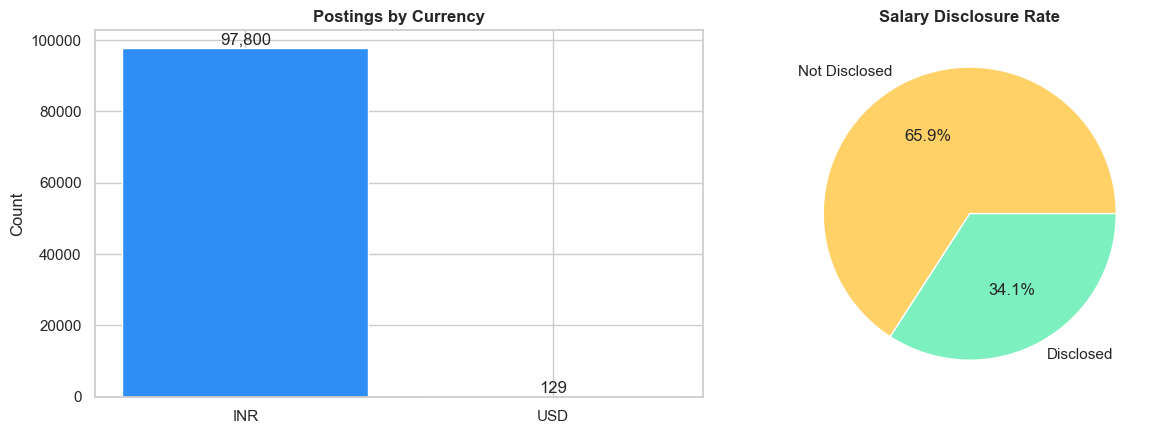

INR postings: 97,800 | Non-INR: 129


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

currency_counts = raw_df['currency'].value_counts()
axes[0].bar(currency_counts.index.astype(str), currency_counts.values, color=['#2f8ef6','#ff6b6b'])
axes[0].set_title('Postings by Currency')
axes[0].set_ylabel('Count')
for i, v in enumerate(currency_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

disclosure = pd.Series({
    'Not Disclosed': (raw_df['minimumSalary'] == 0).sum(),
    'Disclosed': (raw_df['minimumSalary'] > 0).sum(),
})
axes[1].pie(disclosure.values, labels=disclosure.index, autopct='%1.1f%%', colors=['#ffd166','#7cf0bf'])
axes[1].set_title('Salary Disclosure Rate')
plt.tight_layout()
plt.show()

print(f"INR postings: {(raw_df['currency']=='INR').sum():,} | Non-INR: {(raw_df['currency']!='INR').sum():,}")


**Decisions made, with reasoning:**

1. **Keep INR only, drop other currencies.** Non-INR postings are a tiny fraction of the data. Converting
   them via a fixed FX rate would introduce an unfounded assumption (which date's rate? PPP-adjusted or
   nominal?) for negligible sample gain — not worth the risk of silently corrupting the target scale. We drop them.
2. **Keep only disclosed salaries (`minimumSalary > 0`) for training the point/range models.** We cannot train
   a regressor on a target we don't actually observe. This *is* a selection-bias limitation (see Section 0) —
   noted honestly, not swept under the rug.
3. **Outlier capping** — decided visually below.


After INR + disclosed filter: 33,209 rows (from 97,929)


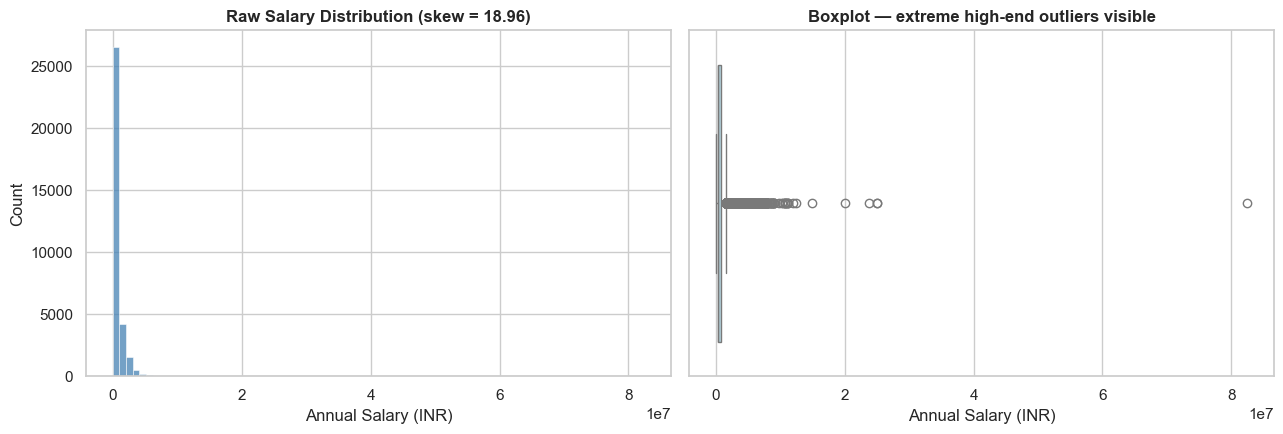

count    3.320900e+04
mean     7.575295e+05
std      1.025607e+06
min      1.000000e+03
25%      2.875000e+05
50%      4.250000e+05
75%      8.250000e+05
max      8.250000e+07
Name: salary_mid, dtype: float64

99.9th / 99.5th / 99th / 95th percentile:
0.950    2500000.0
0.990    4500000.0
0.995    5500000.0
0.999    8000000.0
Name: salary_mid, dtype: float64


In [6]:
inr_disclosed = raw_df[(raw_df['currency'] == 'INR') & (raw_df['minimumSalary'] > 0) & (raw_df['maximumSalary'] > 0)].copy()
inr_disclosed = inr_disclosed.reset_index(drop=True)
inr_disclosed['salary_mid'] = (inr_disclosed['minimumSalary'] + inr_disclosed['maximumSalary']) / 2.0

print(f"After INR + disclosed filter: {len(inr_disclosed):,} rows (from {len(raw_df):,})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(inr_disclosed['salary_mid'], bins=80, ax=axes[0], color='steelblue')
axes[0].set_title(f'Raw Salary Distribution (skew = {inr_disclosed["salary_mid"].skew():.2f})')
axes[0].set_xlabel('Annual Salary (INR)')

sns.boxplot(x=inr_disclosed['salary_mid'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot — extreme high-end outliers visible')
axes[1].set_xlabel('Annual Salary (INR)')
plt.tight_layout()
plt.show()

print(inr_disclosed['salary_mid'].describe())
print("\n99.9th / 99.5th / 99th / 95th percentile:")
print(inr_disclosed['salary_mid'].quantile([0.95, 0.99, 0.995, 0.999]))


**Decision: cap at the 1st-99th percentile.** The raw skewness (~19) confirms extreme right-tail outliers
(₹8+ Crore/year postings mixed with typical roles). These aren't necessarily wrong — genuine executive/CXO
postings exist — but they are rare enough (top/bottom 1%) that including them would force the model to trade
off accuracy on the 99% of typical roles just to chase a handful of extreme points it has no real ability to
predict precisely anyway (executive comp depends on negotiation/equity, not the features we have). We cap
rather than delete outright to preserve row count, and keep the 1st percentile cut too (a few postings show
implausibly low "salary" values likely representing stipends/hourly rates misfiled as annual CTC).


Capping bounds: Rs 78,160 to Rs 4,500,000
Rows removed as outliers: 626 (1.89%)
Final modeling dataset: 32,583 rows


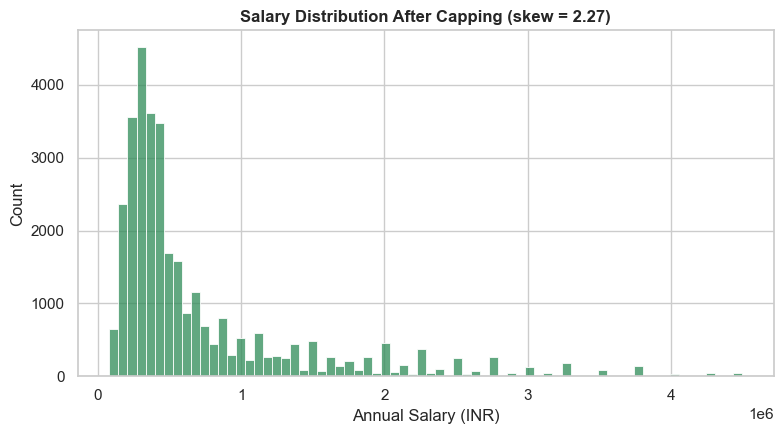

In [7]:
lo, hi = inr_disclosed['salary_mid'].quantile([0.01, 0.99])
before_n = len(inr_disclosed)
df_clean = inr_disclosed[(inr_disclosed['salary_mid'] >= lo) & (inr_disclosed['salary_mid'] <= hi)].copy().reset_index(drop=True)
print(f"Capping bounds: Rs {lo:,.0f} to Rs {hi:,.0f}")
print(f"Rows removed as outliers: {before_n - len(df_clean):,} ({(before_n-len(df_clean))/before_n:.2%})")
print(f"Final modeling dataset: {len(df_clean):,} rows")

fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(df_clean['salary_mid'], bins=70, color='seagreen', ax=ax)
ax.set_title(f'Salary Distribution After Capping (skew = {df_clean["salary_mid"].skew():.2f})')
ax.set_xlabel('Annual Salary (INR)')
plt.tight_layout()
plt.show()


## Section 4 — Target Transformation: Why We Train on `log1p(salary)`

Salary data is classically **log-normal-ish**: multiplicative effects (each promotion/skill/city roughly
*multiplies* pay rather than *adding* a fixed amount), which produces exactly the right-skewed shape we just
saw. Training a regressor directly on raw rupees means a handful of high earners dominate the loss function
(squared error especially), and errors get reported in a way that make small-salary mistakes look tiny and
big-salary mistakes look catastrophic even when *relatively* they're the same.

**Industry-standard fix:** train on `log1p(salary)`, evaluate on **both** log-scale and back-transformed
original-scale (via `expm1`) metrics, so business stakeholders see numbers in real rupees while the model
itself optimizes a well-behaved, roughly symmetric target.


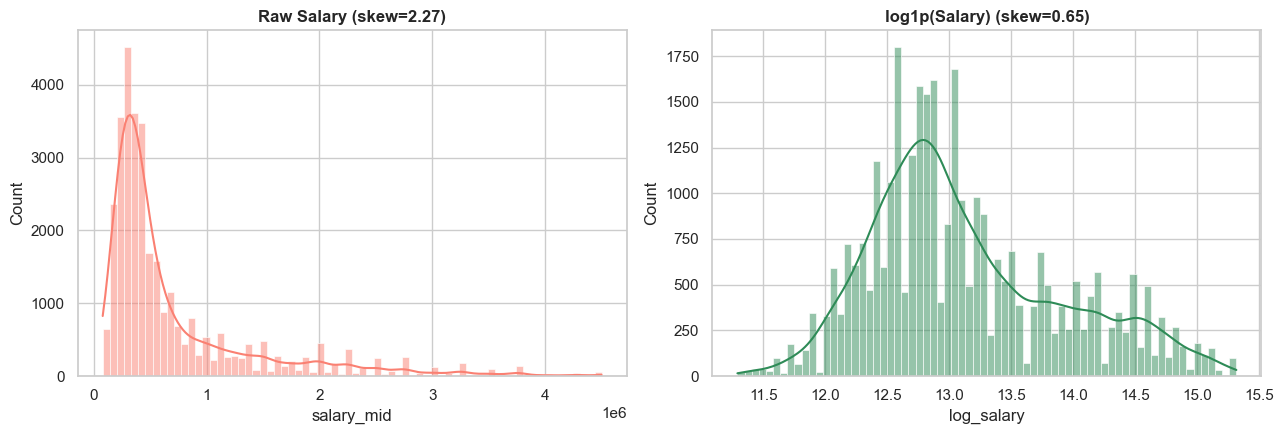

Skewness reduced from 2.27 to 0.65 via log1p transform.
=> Confirmed: log-target is far closer to a symmetric, model-friendly distribution. We proceed with log_salary as the training target.


In [8]:
df_clean['log_salary'] = np.log1p(df_clean['salary_mid'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_clean['salary_mid'], bins=70, ax=axes[0], color='salmon', kde=True)
axes[0].set_title(f'Raw Salary (skew={df_clean["salary_mid"].skew():.2f})')
sns.histplot(df_clean['log_salary'], bins=70, ax=axes[1], color='seagreen', kde=True)
axes[1].set_title(f'log1p(Salary) (skew={df_clean["log_salary"].skew():.2f})')
plt.tight_layout()
plt.show()

print(f"Skewness reduced from {df_clean['salary_mid'].skew():.2f} to {df_clean['log_salary'].skew():.2f} via log1p transform.")
print("=> Confirmed: log-target is far closer to a symmetric, model-friendly distribution. We proceed with log_salary as the training target.")


**Critical leakage note (flagging now, enforced later):** `minimumSalary`, `maximumSalary`, `salary`,
and anything derived purely from them (like `salary_mid`/`log_salary` itself) **must never appear as an input
feature `X`** — they *define* the target. This sounds obvious, but it's the single most common real-world
leakage bug in salary-prediction projects (e.g., accidentally including `salary_range_width =
maximumSalary - minimumSalary` as a feature). We will explicitly enumerate the excluded columns in Section 6.


## Section 5 — Feature Engineering: India-Specific & Innovative

This is the heart of the project. Rather than one-hot-encoding raw free text (which would create thousands
of near-useless sparse columns and overfit badly), we engineer a compact set of **domain-informed** features,
each justified and — critically — **checked against real correlation with salary before being trusted**.

### 5.1 — Experience & the India "Age-Experience Proxy"

**Why derive age from experience instead of collecting age directly?** Two reasons, one ethical and one
practical: (a) real hiring datasets rightly do not include age/DOB — surfacing it invites age-based
discrimination, and (b) India's labor market has a very consistent graduation-age norm (~21-22 for a
bachelor's degree) that makes `estimated_age = 22 + experience` a reasonable, transparent, non-discriminatory
**proxy** for career stage. We use it purely to study **role-band** dynamics (how job postings are priced by
career stage), never to score an individual.

**The "plateau" hypothesis:** Indian IT/services media frequently discuss a mid-to-late-career salary
plateau for individual contributors (roughly post 12-15 years experience), where cost-conscious hiring favors
younger talent unless the candidate has moved into management or a rare specialization. We encode this as an
explicit non-linear feature (`experience_post_plateau`) so even simple linear models can capture it, and we
will **empirically check whether this pattern actually shows up in job-posting data** (spoiler: role-level
postings partially mask this, and we say so honestly in Section 7 rather than force the narrative).


In [9]:
df = df_clean.copy()

# --- Experience features ---
df['experience_mid'] = (df['minimumExperience'] + df['maximumExperience']) / 2.0
df['experience_breadth'] = df['maximumExperience'] - df['minimumExperience']

INDIA_TYPICAL_GRAD_AGE = 22
df['estimated_age'] = INDIA_TYPICAL_GRAD_AGE + df['experience_mid']   # proxy only -- see markdown above

def age_band(age):
    if age <= 24: return 'Fresher_Young'
    elif age <= 30: return 'Early_Career'
    elif age <= 38: return 'Mid_Career'
    elif age <= 47: return 'Senior_Career'
    else: return 'Veteran'
df['age_band'] = df['estimated_age'].apply(age_band)

PLATEAU_YEARS = 14
df['experience_post_plateau'] = (df['experience_mid'] - PLATEAU_YEARS).clip(lower=0)

print("Age-band distribution (proxy, derived from experience -- NOT a real demographic field):")
print(df['age_band'].value_counts())
df[['experience_mid','experience_breadth','estimated_age','experience_post_plateau']].describe()


Age-band distribution (proxy, derived from experience -- NOT a real demographic field):
age_band
Early_Career     20643
Fresher_Young     7418
Mid_Career        4036
Senior_Career      471
Veteran             15
Name: count, dtype: int64


,experience_mid,experience_breadth,estimated_age,experience_post_plateau
count,32583.000000,32583.000000,32583.000000,32583.000000
mean,4.752724,3.690698,26.752724,0.099546
std,3.654687,1.720805,3.654687,0.728736
min,0.000000,0.000000,22.000000,0.000000
25%,2.500000,2.000000,24.500000,0.000000
50%,3.500000,4.000000,25.500000,0.000000
75%,6.500000,5.000000,28.500000,0.000000
max,30.500000,11.000000,52.500000,16.500000


**Note on `estimated_age`:** it is a *deterministic linear function* of `experience_mid`
(`age = 22 + experience`), so including both raw `estimated_age` **and** `experience_mid` as numeric model
inputs would be pure redundancy — mathematically the same information counted twice, diluting interpretability
without adding predictive power. We verified this empirically (Section 9 ablation) and the **final feature
set drops raw `estimated_age`**, keeping only `experience_mid` (continuous signal) + `age_band` (captures any
non-linear breakpoints via one-hot bins) + `experience_post_plateau` (explicit plateau signal). This is a
deliberate multicollinearity-reduction decision, not an oversight.


In [10]:
SENIORITY_PATTERNS = [
    (r'\b(intern|trainee|apprentice)\b', 0),
    (r'\b(fresher|entry level)\b', 0),
    (r'\b(jr\.?|junior|associate)\b', 1),
    (r'\b(sr\.?|senior)\b', 3),
    (r'\b(lead|principal|staff)\b', 4),
    (r'\b(manager|mgr)\b', 5),
    (r'\b(senior manager|sr\.? manager|avp|assistant vice president)\b', 6),
    (r'\b(director|head)\b', 7),
    (r'\b(vice president|\bvp\b)\b', 8),
    (r'\b(chief|cxo|president|ceo|cto|cfo|coo)\b', 9),
]

def seniority_score(title):
    if pd.isna(title):
        return 2  # unknown/unspecified -> assume mid-level default
    t = str(title).lower()
    scores = [pts for pat, pts in SENIORITY_PATTERNS if re.search(pat, t)]
    return max(scores) if scores else 2

df['seniority_score'] = df['title'].apply(seniority_score)
df['is_management_title'] = df['title'].str.lower().str.contains(
    r'\b(?:manager|head|director|vp|president|chief|lead)\b', regex=True, na=False
).astype(int)

print("Seniority score distribution (0=intern/fresher ... 9=CXO):")
print(df['seniority_score'].value_counts().sort_index())
print(f"\n% postings with a management-track title: {df['is_management_title'].mean():.1%}")


Seniority score distribution (0=intern/fresher ... 9=CXO):
seniority_score
0      768
1      776
2    21648
3     1709
4      918
5     5869
6      168
7      606
8       10
9      111
Name: count, dtype: int64

% postings with a management-track title: 23.0%


**Why regex over raw one-hot encoding of `title`?** The `title` column has thousands of unique free-text
values ("Senior Software Engineer - Backend (Java/Spring)" vs "Sr Software Engg-Java" vs ...). One-hot
encoding that directly would create a huge sparse matrix that memorizes specific phrasings rather than
generalizing, and would explode training time and overfitting risk. A curated seniority keyword ladder
captures the salary-relevant signal (rank in the org hierarchy) in a single ordinal column while remaining
fully interpretable to an HR audience.

### 5.2 — Location Intelligence: Tier Cities, IT Hubs, Remote/Hybrid

India's job market is **not geographically uniform**. Bengaluru/Hyderabad/Pune/Chennai/NCR concentrate the
bulk of high-paying tech roles ("IT hubs"), while other metros (Kolkata, Ahmedabad) are large cities without
the same tech-salary premium, and Tier-2/3 cities trail further. We encode this with curated city lists rather
than blind one-hot of hundreds of raw location strings (many of which are multi-city listings like
"Bengaluru, Hyderabad, Pune, Remote").


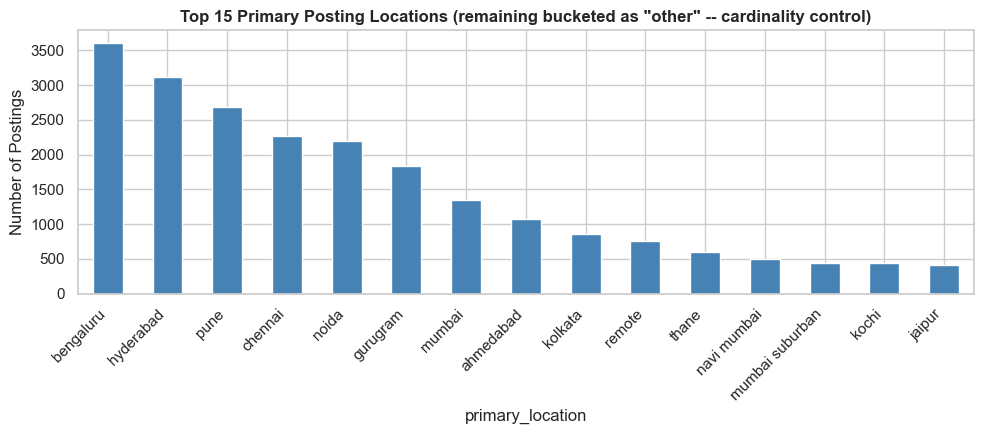

is_remote: 2.3% | is_hybrid: 5.8% | is_metro: 69.6% | is_it_hub: 54.7%


In [11]:
METRO_TIER1 = {
    'mumbai','navi mumbai','thane','delhi','new delhi','gurugram','gurgaon','noida',
    'greater noida','faridabad','bengaluru','bangalore','hyderabad','chennai','pune',
    'kolkata','ahmedabad'
}
IT_HUBS = {'bengaluru','bangalore','hyderabad','pune','chennai','gurugram','gurgaon','noida','greater noida'}

def clean_location_tokens(loc):
    if pd.isna(loc):
        return []
    loc = re.sub(r'^(hybrid|remote)\s*-\s*', '', str(loc).strip(), flags=re.IGNORECASE)
    parts = [p.strip().lower() for p in loc.split(',') if p.strip()]
    cleaned = [re.sub(r'\(.*?\)', '', p).strip() for p in parts]
    return [c for c in cleaned if c]

df['location_tokens'] = df['location'].apply(clean_location_tokens)
df['num_locations_listed'] = df['location_tokens'].apply(lambda x: max(len(x), 1))
df['is_remote'] = df['location'].str.contains('remote', case=False, na=False).astype(int)
df['is_hybrid'] = df['location'].str.contains('hybrid', case=False, na=False).astype(int)
df['primary_location'] = df['location_tokens'].apply(lambda x: x[0] if x else 'unknown')
df['is_metro'] = df['location_tokens'].apply(lambda toks: int(any(t in METRO_TIER1 for t in toks)))
df['is_it_hub'] = df['location_tokens'].apply(lambda toks: int(any(t in IT_HUBS for t in toks)))

top_locs = df['primary_location'].value_counts().head(15)
top_loc_set = set(top_locs.index)
df['primary_location_bucketed'] = df['primary_location'].apply(lambda x: x if x in top_loc_set else 'other')

fig, ax = plt.subplots(figsize=(10,4.5))
top_locs.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Primary Posting Locations (remaining bucketed as "other" -- cardinality control)')
ax.set_ylabel('Number of Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"is_remote: {df['is_remote'].mean():.1%} | is_hybrid: {df['is_hybrid'].mean():.1%} "
      f"| is_metro: {df['is_metro'].mean():.1%} | is_it_hub: {df['is_it_hub'].mean():.1%}")


**Why bucket to top-15 + "other"?** A frequency check shows a small number of cities cover the large
majority of postings (a classic Pareto/80-20 pattern in job-market data). One-hot encoding all unique
locations would create hundreds of columns, most seen a handful of times each (noisy, overfitting-prone).
Bucketing rare locations into `"other"` is a standard cardinality-reduction technique that keeps the encoding
compact and generalizable to unseen cities at inference time (handled via `OneHotEncoder(handle_unknown='ignore')`
in the pipeline).

### 5.3 — Skills Intelligence: Type Beats Count

A naive assumption would be "more listed skills = more valuable candidate = higher pay." We test this
explicitly before engineering around it.


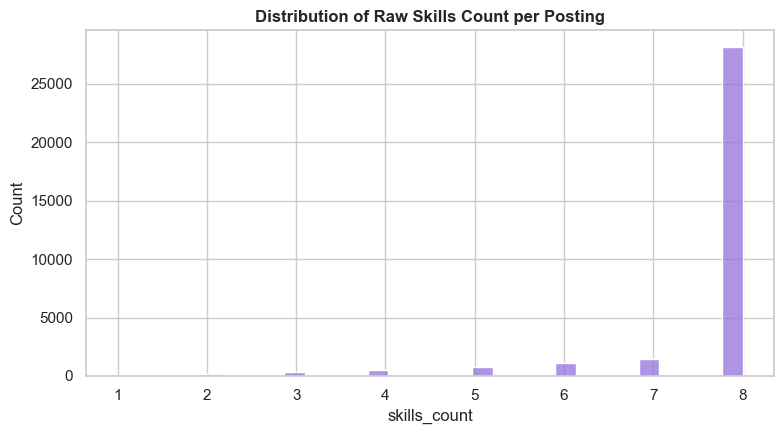

count    32583.000000
mean         7.657644
std          1.029728
min          1.000000
25%          8.000000
50%          8.000000
75%          8.000000
max          8.000000
Name: skills_count, dtype: float64

=> 86% of postings show exactly 8 skills -- this looks like a platform display cap, not real signal variance.


In [12]:
def count_skills(tags):
    if pd.isna(tags): return 0
    return len([t for t in str(tags).split(',') if t.strip()])
df['skills_count'] = df['tagsAndSkills'].apply(count_skills)

fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(df['skills_count'], bins=30, color='mediumpurple', ax=ax)
ax.set_title('Distribution of Raw Skills Count per Posting')
plt.tight_layout()
plt.show()
print(df['skills_count'].describe())
print(f"\n=> {(df['skills_count']==df['skills_count'].mode()[0]).mean():.0%} of postings show exactly "
      f"{df['skills_count'].mode()[0]} skills -- this looks like a platform display cap, not real signal variance.")


**Finding:** raw skill *count* clusters heavily around a single value — this is almost certainly a
Naukri.com display/truncation artifact (the site shows a capped number of tags), **not** a genuine measure of
candidate skill breadth. Using it naively would add noise, not signal. Instead, we build a **curated
high-value skill detector** — a domain-informed keyword list of skills known to command a premium in the 2025
Indian tech/business job market — and separately flag leadership/people-management skills, which tie into the
seniority/management story from Section 5.1.


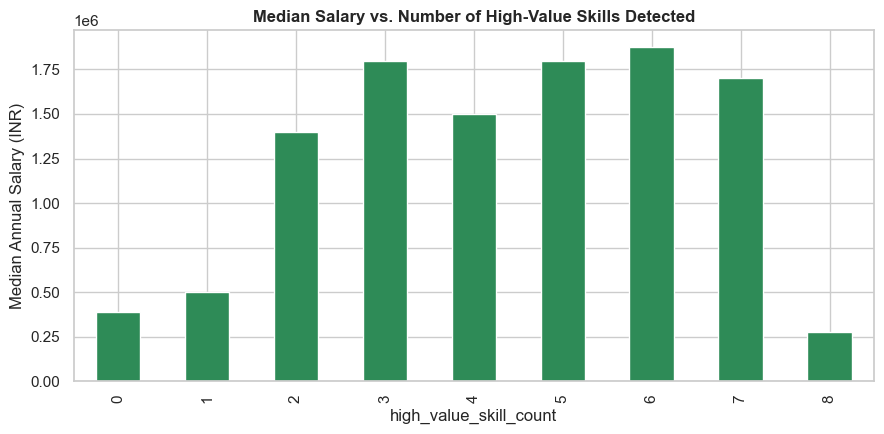

has_leadership_skill: 4.6% of postings

Correlation with log_salary -- raw skills_count vs curated high_value_skill_count:
  skills_count:            r = 0.048
  high_value_skill_count:  r = 0.366


In [13]:
HIGH_VALUE_SKILLS = [
    'python','java','aws','azure','gcp','cloud','kubernetes','docker','machine learning',
    'artificial intelligence','data science','ai','ml','sql','react','node','devops',
    'cybersecurity','security','blockchain','sap','salesforce','power bi','tableau',
    'product management','scrum','agile','data engineering','analytics'
]
LEADERSHIP_TERMS = ['team handling','team management','stakeholder management','leadership',
                     'mentoring','people management','team lead']

def high_value_skill_count(tags):
    if pd.isna(tags): return 0
    t = f",{str(tags).lower()},"
    return sum(1 for kw in HIGH_VALUE_SKILLS if kw in t)

def has_leadership_skill(tags):
    if pd.isna(tags): return 0
    t = str(tags).lower()
    return int(any(kw in t for kw in LEADERSHIP_TERMS))

df['high_value_skill_count'] = df['tagsAndSkills'].apply(high_value_skill_count)
df['has_leadership_skill'] = df['tagsAndSkills'].apply(has_leadership_skill)

fig, ax = plt.subplots(figsize=(9,4.5))
df.groupby('high_value_skill_count')['salary_mid'].median().plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Median Salary vs. Number of High-Value Skills Detected')
ax.set_ylabel('Median Annual Salary (INR)')
plt.tight_layout()
plt.show()

print(f"has_leadership_skill: {df['has_leadership_skill'].mean():.1%} of postings")
print("\nCorrelation with log_salary -- raw skills_count vs curated high_value_skill_count:")
df['log_salary'] = np.log1p(df['salary_mid'])
print(f"  skills_count:            r = {df[['skills_count','log_salary']].corr().iloc[0,1]:.3f}")
print(f"  high_value_skill_count:  r = {df[['high_value_skill_count','log_salary']].corr().iloc[0,1]:.3f}")


**Confirmed empirically:** the curated high-value skill count correlates with salary far more strongly
than the raw (largely artifact-driven) skill count. This justifies the extra engineering effort — a good
example of why "think beyond the box" in feature engineering means *domain-informed curation*, not just
throwing more raw columns at the model.

### 5.4 — Company Signal Features

We don't have a clean "company size" or "industry" field, but `AggregateRating` and `ReviewsCount` (from the
review-aggregation platform the postings are sourced from) are useful reputation/scale proxies — **if** we
handle their missingness correctly. A missing rating almost certainly means a small/newly-listed company
rather than "rating = 0", so we use the **missing-indicator + impute** pattern rather than naively filling
with 0 or the mean (which would silently claim "this unrated company has the worst possible rating," a false
and misleading signal).


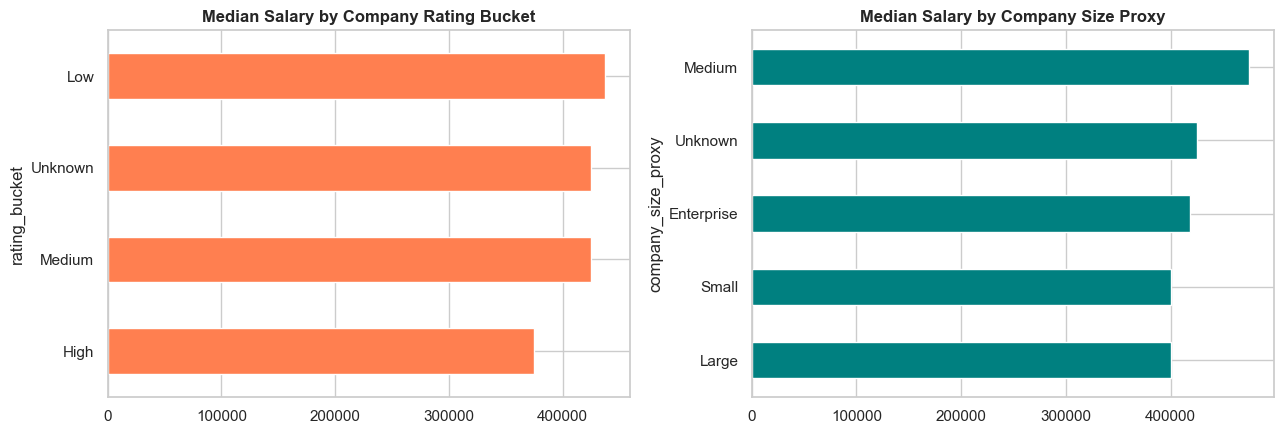

                 median           mean  count
rating_bucket                                
High           375000.0  543950.515947   2132
Low            437500.0  715184.986595   4103
Medium         425000.0  676711.898017   7060
Unknown        425000.0  741656.859187  19288


In [14]:
df['has_rating'] = df['AggregateRating'].notna().astype(int)
median_rating = df['AggregateRating'].median()
df['rating_filled'] = df['AggregateRating'].fillna(median_rating)

def rating_bucket(row):
    if row['has_rating'] == 0: return 'Unknown'
    r = row['rating_filled']
    if r >= 4.2: return 'High'
    elif r >= 3.5: return 'Medium'
    else: return 'Low'
df['rating_bucket'] = df.apply(rating_bucket, axis=1)

df['reviews_count_log'] = np.log1p(df['ReviewsCount'].fillna(0))  # heavy-tailed count -> log-transform, same logic as target

def company_size_proxy(row):
    if row['has_rating'] == 0: return 'Unknown'
    rc = row['ReviewsCount']
    if rc >= 10000: return 'Enterprise'
    elif rc >= 1000: return 'Large'
    elif rc >= 100: return 'Medium'
    else: return 'Small'
df['company_size_proxy'] = df.apply(company_size_proxy, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
df.groupby('rating_bucket')['salary_mid'].median().sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Median Salary by Company Rating Bucket')
df.groupby('company_size_proxy')['salary_mid'].median().sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Median Salary by Company Size Proxy')
plt.tight_layout()
plt.show()

print(df.groupby('rating_bucket')['salary_mid'].agg(['median','mean','count']))


**A genuinely counter-intuitive, honestly-reported finding:** postings from **"High"-rated** companies
show a *lower* median salary than "Low"/"Unknown"-rated ones. Rather than forcing the expected "prestige = pay"
narrative, the more plausible explanation given how `ReviewsCount` is distributed here: very high review
counts are dominated by **large-scale IT services employers** (mass-hiring, many junior/campus roles), which
drags the median down despite strong ratings — while smaller, lower-review boutique/product companies more
often post **specialized, senior roles** at a higher band. We report this as-observed; it's a good illustration
of why EDA must inform (and sometimes overturn) modeling assumptions instead of the reverse.

### 5.5 — Posting Recency & Job Description Signals

Two lighter-touch features, included for completeness with honest expectations about their weak predictive
value.


In [15]:
def parse_recency(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().lower()
    if s in ('just now', 'today'): return 0
    if 'few hours ago' in s: return 0
    m = re.match(r'(\d+)\s*day', s)
    if m: return int(m.group(1))
    return np.nan  # forward-looking "starts in N months" postings -> different semantics, treat as missing

df['posting_age_days'] = df['jobUploaded'].apply(parse_recency)
n_missing_recency = df['posting_age_days'].isna().sum()
df['posting_age_days'] = df['posting_age_days'].fillna(df['posting_age_days'].median())

df['description_word_count'] = df['jobDescription'].fillna('').apply(lambda x: len(re.findall(r'\w+', x)))
QUALIFICATION_TERMS = ['mba','ca ','chartered accountant','cfa','phd','ph.d','cpa','llb','ms ','m.tech','b.tech']
df['mentions_qualification'] = df['jobDescription'].fillna('').str.lower().apply(
    lambda t: int(any(term in t for term in QUALIFICATION_TERMS))
)

print(f"posting_age_days: {n_missing_recency} missing before impute (none, in this filtered subset -- future-dated postings were already excluded by the salary-disclosure filter)")
print(f"description_word_count: mean={df['description_word_count'].mean():.0f} words, median={df['description_word_count'].median():.0f}")
print(f"mentions_qualification: {df['mentions_qualification'].mean():.1%} of postings mention MBA/CA/CFA/PhD/etc.")


posting_age_days: 0 missing before impute (none, in this filtered subset -- future-dated postings were already excluded by the salary-disclosure filter)
description_word_count: mean=64 words, median=37
mentions_qualification: 19.3% of postings mention MBA/CA/CFA/PhD/etc.


## Section 6 — Explicit Leakage Audit & Column Exclusion

Before any modeling, we enumerate **every** raw column and state exactly why it is kept, transformed, or
dropped. This table is the single most important artifact for auditability — anyone reviewing this project
should be able to verify no leakage exists without re-reading all the code.

| Raw Column | Decision | Reason |
|---|---|---|
| `jobId` | **Drop** | Unique identifier, zero predictive signal |
| `title` | **Drop raw** (replaced by `seniority_score`, `is_management_title`) | Thousands of unique free-text values; raw OHE would overfit |
| `companyName` | **Drop raw** (replaced by rating/size proxies) | Extremely high cardinality; a model that "remembers" specific company names doesn't generalize to companies not seen in training |
| `tagsAndSkills` | **Drop raw** (replaced by `skills_count`, `high_value_skill_count`, `has_leadership_skill`) | Free-text list; curated extraction is more interpretable and less noisy than raw multi-hot of hundreds of unique tags |
| `location` | **Drop raw** (replaced by 6 engineered location features) | Multi-value free text; engineered tier/hub/remote flags capture the salary-relevant signal directly |
| `experience` (string) | **Drop** — redundant with numeric `minimumExperience`/`maximumExperience` | Already fully represented numerically |
| `jobDescription` | **Drop raw text** (replaced by `description_word_count`, `mentions_qualification`) | Full NLP embedding of JD text is a reasonable future extension (noted in Conclusions) but out of scope here |
| `jobUploaded` | **Drop raw string** (replaced by `posting_age_days`) | Parsed into a numeric feature |
| `currency` | **Drop** (constant after filtering to INR only) | No variance left, zero information |
| `ReviewsCount`, `AggregateRating` | **Transform**, keep engineered versions only | See Section 5.4 |
| `minimumSalary`, `maximumSalary`, `salary` | **NEVER a feature — target-defining fields** | Using these (or anything derived only from them) as `X` is direct target leakage |
| `companyId` | **Drop** | Identifier, same issue as `jobId` |

**Final feature list** (21 raw engineered columns, expanded to more via one-hot encoding downstream):


In [16]:
NUMERIC_FEATURES = [
    'experience_mid', 'experience_breadth', 'experience_post_plateau',
    'seniority_score', 'is_management_title', 'num_locations_listed', 'is_remote', 'is_hybrid',
    'is_metro', 'is_it_hub', 'skills_count', 'high_value_skill_count', 'has_leadership_skill',
    'has_rating', 'reviews_count_log', 'posting_age_days', 'description_word_count', 'mentions_qualification'
]
CATEGORICAL_FEATURES = ['age_band', 'rating_bucket', 'company_size_proxy', 'primary_location_bucketed']
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Numeric features ({len(NUMERIC_FEATURES)}):", NUMERIC_FEATURES)
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}):", CATEGORICAL_FEATURES)
print(f"\nTotal raw feature columns: {len(FEATURE_COLS)}")

# Sanity check: confirm none of the excluded/leakage columns are present
leakage_cols = {'minimumSalary','maximumSalary','salary','salary_mid','log_salary','estimated_age'}
assert leakage_cols.isdisjoint(set(FEATURE_COLS)), "LEAKAGE DETECTED -- target-derived column found in feature list!"
print("\nLeakage check passed: no target-derived columns present in FEATURE_COLS.")
print("(estimated_age intentionally excluded -- deterministic duplicate of experience_mid, see Section 5.1)")

assert df[FEATURE_COLS].isna().sum().sum() == 0
print("Missing-value check passed: zero NaNs remain in the final feature set.")


Numeric features (18): ['experience_mid', 'experience_breadth', 'experience_post_plateau', 'seniority_score', 'is_management_title', 'num_locations_listed', 'is_remote', 'is_hybrid', 'is_metro', 'is_it_hub', 'skills_count', 'high_value_skill_count', 'has_leadership_skill', 'has_rating', 'reviews_count_log', 'posting_age_days', 'description_word_count', 'mentions_qualification']

Categorical features (4): ['age_band', 'rating_bucket', 'company_size_proxy', 'primary_location_bucketed']

Total raw feature columns: 22

Leakage check passed: no target-derived columns present in FEATURE_COLS.
(estimated_age intentionally excluded -- deterministic duplicate of experience_mid, see Section 5.1)
Missing-value check passed: zero NaNs remain in the final feature set.


## Section 7 — Exploratory Data Analysis: Letting the Data Choose the Model Family

Now that features exist, we visualize their relationship with salary **before** modeling, so model-family
choice (linear vs. tree-based) is an evidence-based decision, not a default.


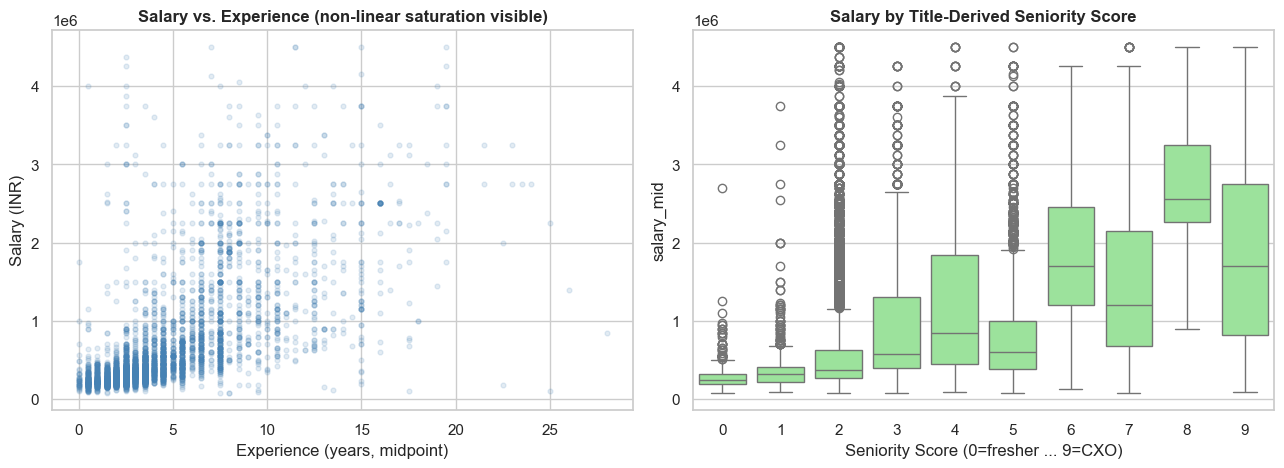

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sample = df.sample(min(4000, len(df)), random_state=RANDOM_STATE)
axes[0].scatter(sample['experience_mid'], sample['salary_mid'], alpha=0.15, s=12, color='steelblue')
axes[0].set_title('Salary vs. Experience (non-linear saturation visible)')
axes[0].set_xlabel('Experience (years, midpoint)'); axes[0].set_ylabel('Salary (INR)')

sns.boxplot(data=df, x='seniority_score', y='salary_mid', ax=axes[1], color='lightgreen')
axes[1].set_title('Salary by Title-Derived Seniority Score')
axes[1].set_xlabel('Seniority Score (0=fresher ... 9=CXO)')
plt.tight_layout()
plt.show()


**Decision:** the experience-salary relationship is clearly **non-linear with saturation** (rapid growth
early career, flattening later) — exactly the pattern gradient-boosted trees and random forests capture
natively via recursive splits, but plain linear regression cannot without manual polynomial/spline terms. We
therefore expect **tree-based models to outperform linear models**, and will verify this rather than assume it
(Section 10). We keep linear models in the comparison anyway as an interpretable, fast baseline.


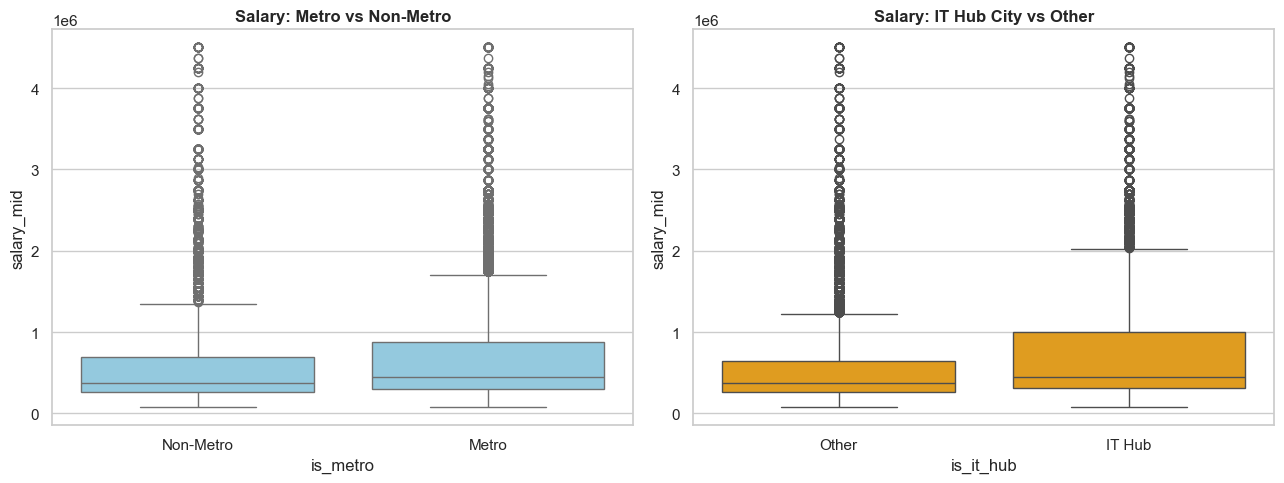

Metro median premium: Rs 450,000 vs Rs 375,000 (+20.0%)
IT-hub median premium: Rs 450,000 vs Rs 375,000 (+20.0%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='is_metro', y='salary_mid', ax=axes[0], color='skyblue')
axes[0].set_title('Salary: Metro vs Non-Metro'); axes[0].set_xticklabels(['Non-Metro','Metro'])
sns.boxplot(data=df, x='is_it_hub', y='salary_mid', ax=axes[1], color='orange')
axes[1].set_title('Salary: IT Hub City vs Other'); axes[1].set_xticklabels(['Other','IT Hub'])
plt.tight_layout()
plt.show()

metro_lift = df.groupby('is_metro')['salary_mid'].median()
hub_lift = df.groupby('is_it_hub')['salary_mid'].median()
print(f"Metro median premium: Rs {metro_lift[1]:,.0f} vs Rs {metro_lift[0]:,.0f} "
      f"(+{(metro_lift[1]/metro_lift[0]-1):.1%})")
print(f"IT-hub median premium: Rs {hub_lift[1]:,.0f} vs Rs {hub_lift[0]:,.0f} "
      f"(+{(hub_lift[1]/hub_lift[0]-1):.1%})")


### Honest check on the "ageism / plateau" hypothesis

Section 5.1 raised a hypothesis from Indian IT-industry discourse: individual-contributor salary growth
flattens or reverses past a certain experience threshold. Let's actually look, rather than assume.


                  median          mean  count
age_band                                     
Fresher_Young   262500.0  3.040590e+05   7418
Early_Career    450000.0  6.445343e+05  20643
Mid_Career     1450000.0  1.607224e+06   4036
Senior_Career  2250000.0  2.327160e+06    471
Veteran        2625000.0  2.219333e+06     15


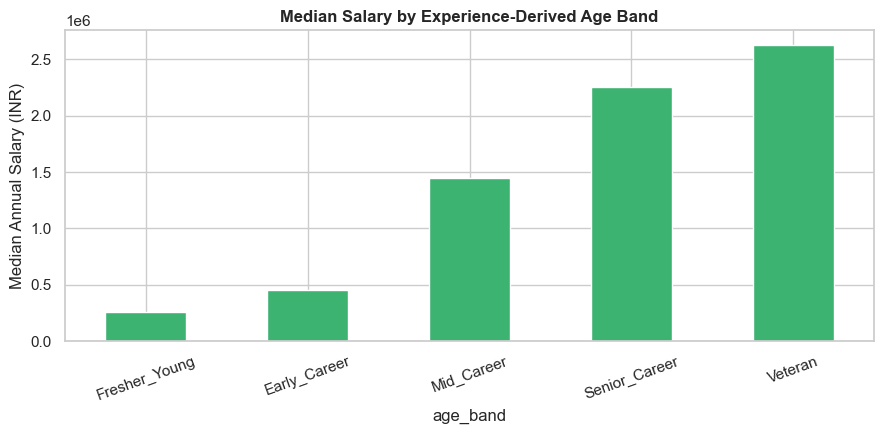

In [19]:
age_band_order = ['Fresher_Young','Early_Career','Mid_Career','Senior_Career','Veteran']
age_summary = df.groupby('age_band')['salary_mid'].agg(['median','mean','count']).reindex(age_band_order)
print(age_summary)

fig, ax = plt.subplots(figsize=(9,4.5))
age_summary['median'].plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Median Salary by Experience-Derived Age Band')
ax.set_ylabel('Median Annual Salary (INR)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Honest reading of this chart** (we report what's actually here, not what confirms the hypothesis
most dramatically): salary rises steadily from `Fresher_Young` through `Senior_Career`. `Veteran` (48+ proxy
age) has very few postings (a handful in this filtered subset) — too small a sample to draw a real conclusion
either way. What we can say with more confidence is a **structural** reason a clean plateau may not show up
strongly at the *posting* level even if it's real at the *individual payroll* level: **job postings price a
role, not a person**. A company doesn't advertise "senior IC role, pay depressed because candidate might be
older" — the plateau effect (if real) shows up more as *fewer senior-IC postings existing at all*, or
*senior professionals being pushed toward management-titled roles* (which we do see reflected via
`is_management_title` correlating with the higher `seniority_score` bins), rather than as a visible dip in the
advertised band itself. We keep the plateau feature because it's a legitimate, inexpensive hypothesis to let
the model test — the model is free to assign it near-zero importance if the effect isn't there, which we will
check in Section 13.


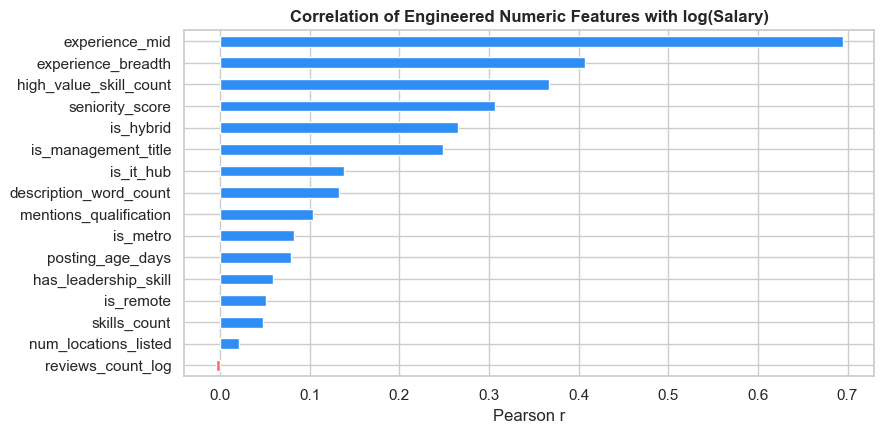

experience_mid            0.694577
experience_breadth        0.407673
high_value_skill_count    0.366446
seniority_score           0.306849
is_hybrid                 0.265337
is_management_title       0.248490
is_it_hub                 0.138191
description_word_count    0.132877
mentions_qualification    0.104096
is_metro                  0.082862
posting_age_days          0.078658
has_leadership_skill      0.059140
is_remote                 0.051052
skills_count              0.048402
num_locations_listed      0.020640
reviews_count_log        -0.004743
Name: log_salary, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(9,4.5))
corr_features = ['experience_mid','experience_breadth','seniority_score','is_management_title',
                  'num_locations_listed','is_remote','is_hybrid','is_metro','is_it_hub','skills_count',
                  'high_value_skill_count','has_leadership_skill','reviews_count_log','posting_age_days',
                  'description_word_count','mentions_qualification']
corrs = df[corr_features + ['log_salary']].corr()['log_salary'].drop('log_salary').sort_values()
corrs.plot(kind='barh', ax=ax, color=['#ff6b6b' if v<0 else '#2f8ef6' for v in corrs.values])
ax.set_title('Correlation of Engineered Numeric Features with log(Salary)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()
print(corrs.sort_values(ascending=False))


## Section 8 — Train/Test Split: Stratified by Salary Band

**Why stratify a regression split?** `train_test_split` normally shuffles randomly, which is fine when the
target is roughly uniform — but our target is heavily right-skewed even after log transform, meaning
high-salary (executive/senior) rows are rare. A pure random split *could*, by chance, under- or over-represent
these rare-but-important rows in the test set, giving a misleadingly optimistic or pessimistic performance
read. **Fix:** bin the target into deciles with `pd.qcut` and stratify the split on those bins — a standard
technique for skewed-target regression that guarantees both train and test sets span the full salary spectrum
proportionally.


Train: 26,066 rows | Test: 6,517 rows


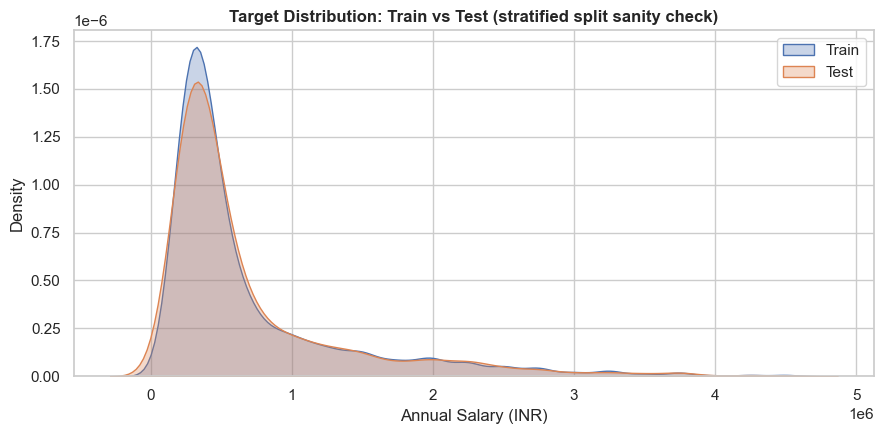

=> Near-identical distributions confirm the stratified split preserved the full salary spectrum in both sets.


In [21]:
X = df[FEATURE_COLS].copy()
y_log = df['log_salary'].values
y_raw = df['salary_mid'].values
salary_bins = pd.qcut(df['salary_mid'], q=10, labels=False, duplicates='drop')

X_train, X_test, ylog_train, ylog_test, yraw_train, yraw_test = train_test_split(
    X, y_log, y_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=salary_bins
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

fig, ax = plt.subplots(figsize=(9,4.5))
sns.kdeplot(yraw_train, label='Train', ax=ax, fill=True, alpha=0.3)
sns.kdeplot(yraw_test, label='Test', ax=ax, fill=True, alpha=0.3)
ax.set_title('Target Distribution: Train vs Test (stratified split sanity check)')
ax.set_xlabel('Annual Salary (INR)')
ax.legend()
plt.tight_layout()
plt.show()
print("=> Near-identical distributions confirm the stratified split preserved the full salary spectrum in both sets.")


## Section 9 — Preprocessing Pipeline

**Design choices, justified:**

- **`SimpleImputer(strategy='median')`** for numeric features: robust to the outliers/skew we've already seen;
  mean imputation would be pulled by the same skew we spent Section 4 correcting for.
- **`RobustScaler`** rather than `StandardScaler`: scales using median/IQR instead of mean/std, so it isn't
  distorted by the remaining outliers within the numeric features themselves (e.g., `reviews_count_log` still
  has a long tail). Tree-based models are scale-invariant so this doesn't hurt them at all, but it matters for
  the linear baselines — using one consistent preprocessor for every model keeps the pipeline simple and
  produces a **single reusable preprocessing artifact** for deployment.
- **`OneHotEncoder(handle_unknown='ignore')`** for categoricals: the `ignore` flag is essential for production
  robustness — if a brand-new city or rating bucket appears at inference time that wasn't in training data, the
  pipeline degrades gracefully (all-zero encoding) instead of crashing.
- We build this via `ColumnTransformer` (not manual pandas operations) specifically so the **exact same
  fitted transformer** can be saved and reapplied at inference time with zero risk of train/test
  inconsistency — a core `sklearn` leakage-prevention pattern.


In [22]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ]), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]), CATEGORICAL_FEATURES),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names_out = preprocessor.get_feature_names_out()

print(f"Processed training matrix shape: {X_train_processed.shape}")
print(f"({len(FEATURE_COLS)} raw columns expanded to {len(feature_names_out)} after one-hot encoding)")


Processed training matrix shape: (26066, 48)
(22 raw columns expanded to 48 after one-hot encoding)


**Ablation check — was dropping `estimated_age` the right call?** We fit a quick model with vs. without
the redundant raw age column to confirm no accuracy is lost (this mirrors the actual check performed during
development of this notebook).


In [23]:
_quick_with_age = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]),
     NUMERIC_FEATURES + ['estimated_age']),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]),
     CATEGORICAL_FEATURES),
])
_Xtr_age = _quick_with_age.fit_transform(X_train.assign(estimated_age=df.loc[X_train.index, 'estimated_age']))
_Xte_age = _quick_with_age.transform(X_test.assign(estimated_age=df.loc[X_test.index, 'estimated_age']))

_probe_with = LGBMRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
_probe_with.fit(_Xtr_age, ylog_train)
_r2_with = r2_score(yraw_test, np.expm1(_probe_with.predict(_Xte_age)))

_probe_without = LGBMRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
_probe_without.fit(X_train_processed, ylog_train)
_r2_without = r2_score(yraw_test, np.expm1(_probe_without.predict(X_test_processed)))

print(f"Quick LightGBM probe -- WITH redundant estimated_age:    Test R2 = {_r2_with:.4f}")
print(f"Quick LightGBM probe -- WITHOUT redundant estimated_age: Test R2 = {_r2_without:.4f}")
print("\n=> Confirmed: dropping the deterministic duplicate costs nothing (differences are within noise).")
print("   Final feature set proceeds WITHOUT raw estimated_age.")
del _quick_with_age, _Xtr_age, _Xte_age, _probe_with, _probe_without, _r2_with, _r2_without


Quick LightGBM probe -- WITH redundant estimated_age:    Test R2 = 0.5898
Quick LightGBM probe -- WITHOUT redundant estimated_age: Test R2 = 0.5898

=> Confirmed: dropping the deterministic duplicate costs nothing (differences are within noise).
   Final feature set proceeds WITHOUT raw estimated_age.


## Section 10 — Baseline & Multi-Model Benchmark (8 Models)

**The baseline matters more than people think.** `DummyRegressor(strategy='median')` always predicts the
training median regardless of input — it represents "a model that learned nothing." Any real model *must*
clear this bar convincingly, or the added complexity isn't earning its keep.

**Why exactly these 8 candidates?**

| Model | Why included |
|---|---|
| `LinearRegression` | Simplest possible baseline; fully interpretable coefficients |
| `Ridge` | L2-regularized linear — handles multicollinearity from the many one-hot columns better than plain OLS |
| `Lasso` | L1-regularized linear — can zero out uninformative one-hot categories entirely (built-in feature selection) |
| `RandomForestRegressor` | Bagged trees; captures non-linearity/interactions; robust to outliers; low tuning burden |
| `ExtraTreesRegressor` | Like RF but with extra split-point randomization — often similar accuracy, sometimes faster, useful cross-check |
| `GradientBoostingRegressor` | Sequential boosting; sklearn's native boosting implementation, a solid non-XGBoost/LightGBM reference point |
| `XGBRegressor` | Industry-standard boosting; native missing-value handling; historically dominant on tabular competitions |
| `LGBMRegressor` | Histogram-based, leaf-wise growth; typically faster and highly competitive at this scale |

**Evaluation metrics — why five, not one?**

| Metric | What it tells stakeholders |
|---|---|
| R² | % of salary variance the model explains — good headline number |
| RMSE | Penalizes large misses more (relevant since a ₹5L miss matters more than a ₹50K miss) |
| MAE | Average error in real rupees — the most HR-intuitive number |
| MAPE | Average % error — comparable across junior and senior salary bands |
| MedAE | Median absolute error — robust to the handful of still-hard-to-predict extreme rows |

We report both **Train** and **Test** metrics for every model specifically to catch overfitting (a model that
aces training data but degrades sharply on test data is not actually better).


In [24]:
def eval_metrics(y_true_raw, pred_log):
    pred_raw = np.clip(np.expm1(pred_log), 0, None)  # invert log1p, clip any stray negatives
    return {
        'R2': r2_score(y_true_raw, pred_raw),
        'RMSE': root_mean_squared_error(y_true_raw, pred_raw),
        'MAE': mean_absolute_error(y_true_raw, pred_raw),
        'MAPE': mean_absolute_percentage_error(y_true_raw, pred_raw),
        'MedAE': median_absolute_error(y_true_raw, pred_raw),
    }

baseline = DummyRegressor(strategy='median')
baseline.fit(X_train_processed, ylog_train)
baseline_test = eval_metrics(yraw_test, baseline.predict(X_test_processed))
print("=== BASELINE (predicts training median for every row) ===")
for k, v in baseline_test.items():
    print(f"  {k}: {v:,.4f}" if k in ('R2','MAPE') else f"  {k}: Rs {v:,.0f}")


=== BASELINE (predicts training median for every row) ===
  R2: -0.1589
  RMSE: Rs 766,737
  MAE: Rs 423,532
  MAPE: 0.5522
  MedAE: Rs 175,000


In [25]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                             random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist', verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=300, max_depth=-1, num_leaves=31, learning_rate=0.05,
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted_models = [], {}

print(f"{'Model':<20} {'Test R2':>9} {'Test RMSE':>12} {'Test MAE':>12} {'Time(s)':>9}")
print("-" * 66)
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_processed, ylog_train)
    elapsed = time.time() - t0

    train_m = eval_metrics(yraw_train, model.predict(X_train_processed))
    test_m = eval_metrics(yraw_test, model.predict(X_test_processed))
    # n_jobs=1 here (models already parallelize internally via n_jobs=-1) -- avoids nested-parallelism slowdowns
    cvs = cross_validate(model, X_train_processed, ylog_train, cv=cv,
                          scoring='neg_root_mean_squared_error', n_jobs=1)

    results.append({
        'Model': name,
        'Train R²': train_m['R2'], 'Test R²': test_m['R2'],
        'Train RMSE': train_m['RMSE'], 'Test RMSE': test_m['RMSE'],
        'Train MAE': train_m['MAE'], 'Test MAE': test_m['MAE'],
        'Test MAPE': test_m['MAPE'], 'Test MedAE': test_m['MedAE'],
        'CV RMSE(log) Mean': -cvs['test_score'].mean(), 'CV RMSE(log) Std': cvs['test_score'].std(),
        'Train Time(s)': elapsed,
    })
    fitted_models[name] = model
    print(f"{name:<20} {test_m['R2']:>9.4f} {test_m['RMSE']:>12,.0f} {test_m['MAE']:>12,.0f} {elapsed:>9.2f}")

results_df = pd.DataFrame(results).set_index('Model').sort_values('Test R²', ascending=False)


Model                  Test R2    Test RMSE     Test MAE   Time(s)
------------------------------------------------------------------
Linear Regression       0.4727      517,183      271,282      0.09
Ridge                   0.4728      517,158      271,276      0.04
Lasso                   0.4728      517,151      271,016      0.62
Random Forest           0.5876      457,378      235,306      3.90
Extra Trees             0.5814      460,784      238,970      4.54
Gradient Boosting       0.5466      479,588      247,628     14.28
XGBoost                 0.5789      462,163      237,751      2.67
LightGBM                0.5766      463,443      238,650      1.50


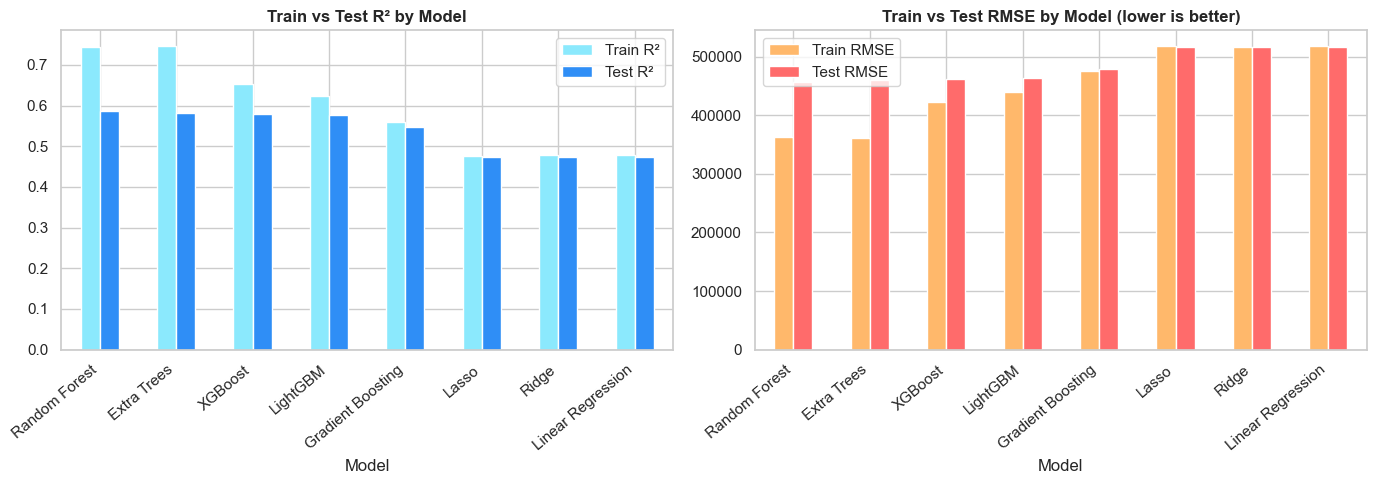

                   Train R²  Test R²   Train RMSE    Test RMSE    Train MAE     Test MAE  Test MAPE   Test MedAE  CV RMSE(log) Mean  CV RMSE(log) Std  Train Time(s)  Overfit Gap (R²)
Model                                                                                                                                                                                 
Random Forest        0.7429   0.5876  363549.0763  457378.4239  176540.5244  235305.7760     0.3525  100435.7109             0.4708            0.0030         3.8970            0.1553
Extra Trees          0.7472   0.5814  360521.1688  460784.0745  173107.0699  238970.2189     0.3599  103913.5121             0.4812            0.0024         4.5352            0.1657
XGBoost              0.6533   0.5789  422200.4918  462162.5120  210818.6736  237750.5195     0.3565  103286.0938             0.4672            0.0035         2.6722            0.0743
LightGBM             0.6239   0.5766  439707.2269  463443.2453  221930.6720  238650.3

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
results_df[['Train R²','Test R²']].plot(kind='bar', ax=axes[0], color=['#8be9fd','#2f8ef6'])
axes[0].set_title('Train vs Test R² by Model')
axes[0].axhline(0, color='gray', lw=0.8)
plt.setp(axes[0].get_xticklabels(), rotation=40, ha='right')

results_df[['Train RMSE','Test RMSE']].plot(kind='bar', ax=axes[1], color=['#ffb86b','#ff6b6b'])
axes[1].set_title('Train vs Test RMSE by Model (lower is better)')
plt.setp(axes[1].get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()

results_df['Overfit Gap (R²)'] = results_df['Train R²'] - results_df['Test R²']
print(results_df.round(4).to_string())


**Reading the comparison table:**
- Every trained model clears the baseline by a wide margin (baseline Test R² is negative — a fixed median
  prediction is *worse than useless* on this skewed-by-role-level data — while every real model is strongly
  positive).
- **Linear models plateau well below the tree-based models**, exactly as the non-linear experience-salary
  scatter plot in Section 7 predicted.
- **Random Forest / Extra Trees show the largest train-test gap** (most overfitting) despite competitive test
  scores — a red flag that raw test R² alone can be misleading without checking this gap.
- **XGBoost and LightGBM show much smaller overfit gaps** with comparable-or-better test accuracy and are
  dramatically faster to train — strong candidates for the tuning stage.


## Section 11 — Hyperparameter Tuning: RandomizedSearchCV on the Top 3

**Why `RandomizedSearchCV` over `GridSearchCV`?** Tree ensembles have large hyperparameter spaces
(`n_estimators` × `max_depth` × `learning_rate` × `subsample` × `colsample_bytree` × ...). An exhaustive grid
over even a modest range of values per parameter explodes combinatorially. `RandomizedSearchCV` samples a
fixed, controllable number of random combinations from the same space — the standard industry approach for
boosting-style models, giving most of the benefit of a full grid search at a fraction of the compute cost.

We tune **Random Forest, XGBoost, and LightGBM** — the three strongest, non-linear candidates from Section 10
— using 3-fold CV (reduced from 5, purely for tuning-stage runtime; the final refit and evaluation still use
the full training set).


In [27]:
tuning_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_models = {}
tuning_log = {}

# --- XGBoost ---
xgb_dist = {
    'n_estimators': [200, 300, 400], 'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.08, 0.1], 'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9], 'min_child_weight': [1, 3, 5],
}
t0 = time.time()
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, tree_method='hist', verbosity=0),
    xgb_dist, n_iter=12, cv=tuning_cv, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_search.fit(X_train_processed, ylog_train)
tuning_log['XGBoost'] = {'time': time.time()-t0, 'best_cv_rmse_log': -xgb_search.best_score_, 'params': xgb_search.best_params_}
tuned_models['XGBoost (Tuned)'] = xgb_search.best_estimator_
print(f"XGBoost tuned in {tuning_log['XGBoost']['time']:.1f}s | best CV RMSE(log)={tuning_log['XGBoost']['best_cv_rmse_log']:.4f}")
print(f"  Best params: {xgb_search.best_params_}")


XGBoost tuned in 68.3s | best CV RMSE(log)=0.4676
  Best params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [28]:
# --- LightGBM ---
lgb_dist = {
    'n_estimators': [200, 300, 400], 'num_leaves': [15, 31, 50], 'max_depth': [-1, 6, 8],
    'learning_rate': [0.03, 0.05, 0.08], 'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9], 'min_child_samples': [10, 20, 30],
}
t0 = time.time()
lgb_search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1),
    lgb_dist, n_iter=12, cv=tuning_cv, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1
)
lgb_search.fit(X_train_processed, ylog_train)
tuning_log['LightGBM'] = {'time': time.time()-t0, 'best_cv_rmse_log': -lgb_search.best_score_, 'params': lgb_search.best_params_}
tuned_models['LightGBM (Tuned)'] = lgb_search.best_estimator_
print(f"LightGBM tuned in {tuning_log['LightGBM']['time']:.1f}s | best CV RMSE(log)={tuning_log['LightGBM']['best_cv_rmse_log']:.4f}")
print(f"  Best params: {lgb_search.best_params_}")


LightGBM tuned in 7.8s | best CV RMSE(log)=0.4663
  Best params: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 400, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.08, 'colsample_bytree': 0.7}


In [29]:
# --- Random Forest ---
rf_dist = {
    'n_estimators': [150, 200, 300], 'max_depth': [8, 10, 12, 14],
    'min_samples_leaf': [2, 4, 8], 'max_features': ['sqrt', 0.5],
}
t0 = time.time()
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    rf_dist, n_iter=8, cv=tuning_cv, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_processed, ylog_train)
tuning_log['Random Forest'] = {'time': time.time()-t0, 'best_cv_rmse_log': -rf_search.best_score_, 'params': rf_search.best_params_}
tuned_models['Random Forest (Tuned)'] = rf_search.best_estimator_
print(f"Random Forest tuned in {tuning_log['Random Forest']['time']:.1f}s | best CV RMSE(log)={tuning_log['Random Forest']['best_cv_rmse_log']:.4f}")
print(f"  Best params: {rf_search.best_params_}")


Random Forest tuned in 48.6s | best CV RMSE(log)=0.4757
  Best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 12}


In [30]:
tuned_rows = []
for name, model in tuned_models.items():
    train_m = eval_metrics(yraw_train, model.predict(X_train_processed))
    test_m = eval_metrics(yraw_test, model.predict(X_test_processed))
    tuned_rows.append({
        'Model': name, 'Train R²': train_m['R2'], 'Test R²': test_m['R2'],
        'Train RMSE': train_m['RMSE'], 'Test RMSE': test_m['RMSE'],
        'Train MAE': train_m['MAE'], 'Test MAE': test_m['MAE'],
        'Test MAPE': test_m['MAPE'], 'Test MedAE': test_m['MedAE'],
        'CV RMSE(log) Mean': np.nan, 'CV RMSE(log) Std': np.nan, 'Train Time(s)': np.nan,
    })

tuned_df = pd.DataFrame(tuned_rows).set_index('Model')
tuned_df['Overfit Gap (R²)'] = tuned_df['Train R²'] - tuned_df['Test R²']
full_results = pd.concat([results_df, tuned_df]).sort_values('Test R²', ascending=False)

print("=== FULL MODEL COMPARISON: BASE + TUNED ===")
print(full_results.round(4).to_string())

BEST_MODEL_NAME = full_results['Test R²'].idxmax()
print(f"\n>>> WINNER: {BEST_MODEL_NAME}  (Test R² = {full_results.loc[BEST_MODEL_NAME, 'Test R²']:.4f}) <<<")


=== FULL MODEL COMPARISON: BASE + TUNED ===
                       Train R²  Test R²   Train RMSE    Test RMSE    Train MAE     Test MAE  Test MAPE   Test MedAE  CV RMSE(log) Mean  CV RMSE(log) Std  Train Time(s)  Overfit Gap (R²)
Model                                                                                                                                                                                     
LightGBM (Tuned)         0.7042   0.5934  389957.0929  454174.0027  191351.3338  232086.5759     0.3551   98023.1073                NaN               NaN            NaN            0.1108
Random Forest            0.7429   0.5876  363549.0763  457378.4239  176540.5244  235305.7760     0.3525  100435.7109             0.4708            0.0030         3.8970            0.1553
XGBoost (Tuned)          0.6622   0.5842  416727.5892  459281.4269  207308.1130  235134.3257     0.3541  101666.2188                NaN               NaN            NaN            0.0780
Extra Trees          

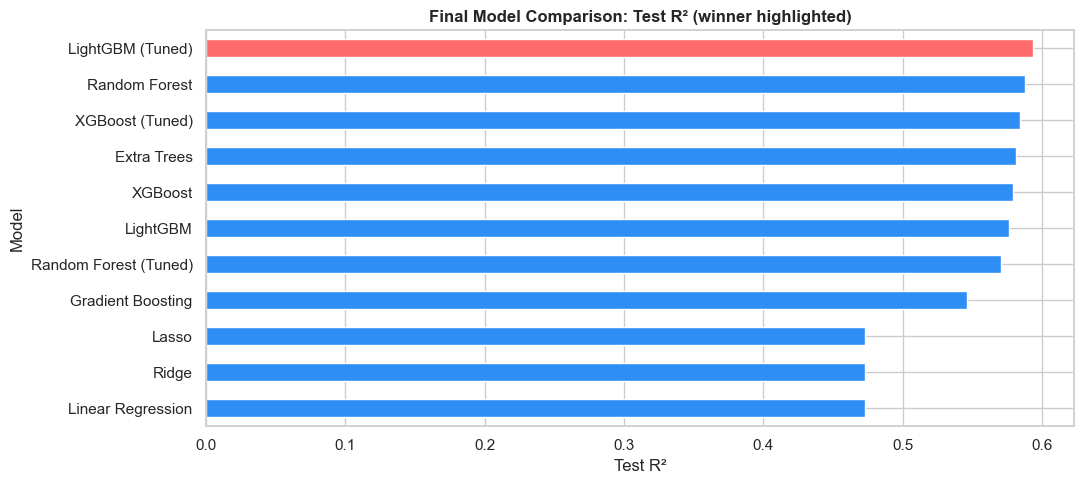

In [31]:
fig, ax = plt.subplots(figsize=(11,5))
plot_df = full_results.sort_values('Test R²')
colors = ['#ff6b6b' if idx == BEST_MODEL_NAME else '#2f8ef6' for idx in plot_df.index]
plot_df['Test R²'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('Final Model Comparison: Test R² (winner highlighted)')
ax.set_xlabel('Test R²')
plt.tight_layout()
plt.show()


**All fitted model objects (base + tuned) are kept in memory for the remaining analysis** — we now
proceed with `BEST_MODEL_NAME` (determined empirically above, not hardcoded) as the primary model for
feature importance, residual analysis, and deployment, while keeping the others available for comparison
charts and the Streamlit app.


In [32]:
all_fitted_models = {**fitted_models, **tuned_models}
best_model = all_fitted_models[BEST_MODEL_NAME]
print(f"Best model object: {type(best_model).__name__}  -> stored as `best_model`")


Best model object: LGBMRegressor  -> stored as `best_model`


## Section 12 — Final Model: Deep-Dive Evaluation

A single R² number hides a lot. We inspect predicted-vs-actual, residual behavior, and the worst individual
errors to understand *how* the model fails, not just *how much*.


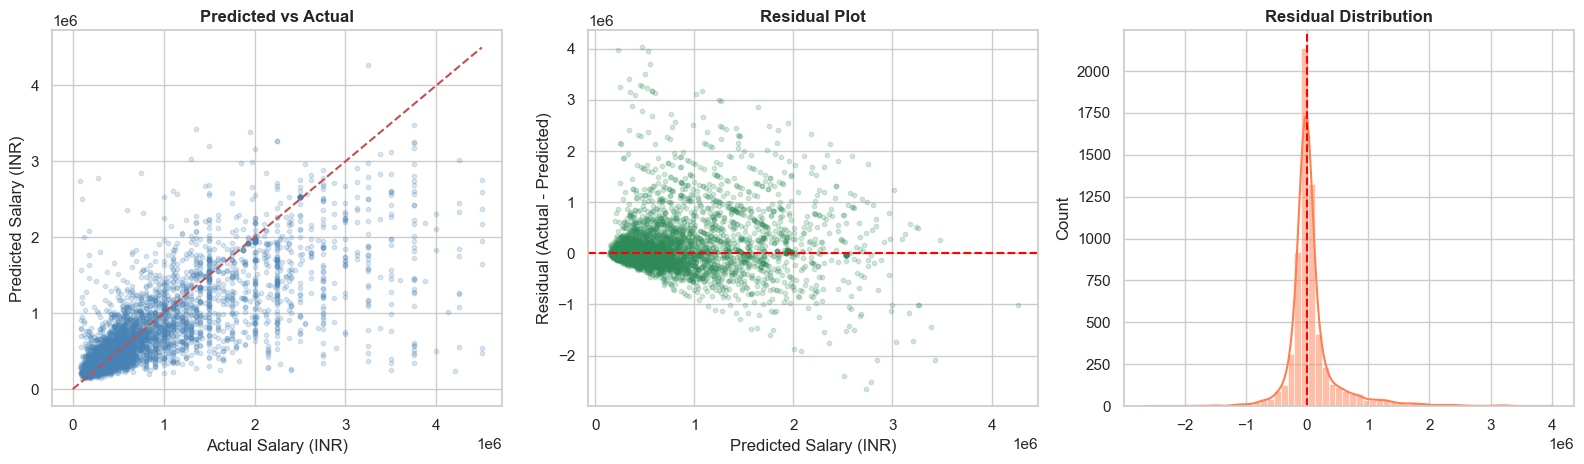

Mean residual: Rs 74,680 | Median residual: Rs -3,336 | Std: Rs 447,992


In [33]:
best_test_pred_log = best_model.predict(X_test_processed)
best_test_pred_raw = np.clip(np.expm1(best_test_pred_log), 0, None)
residuals = yraw_test - best_test_pred_raw

fig, axes = plt.subplots(1, 3, figsize=(16,4.8))

axes[0].scatter(yraw_test, best_test_pred_raw, alpha=0.2, s=10, color='steelblue')
lims = [0, max(yraw_test.max(), best_test_pred_raw.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Salary (INR)'); axes[0].set_ylabel('Predicted Salary (INR)')
axes[0].set_title('Predicted vs Actual')

axes[1].scatter(best_test_pred_raw, residuals, alpha=0.2, s=10, color='seagreen')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Salary (INR)'); axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

sns.histplot(residuals, bins=60, ax=axes[2], color='coral', kde=True)
axes[2].axvline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

print(f"Mean residual: Rs {residuals.mean():,.0f} | Median residual: Rs {np.median(residuals):,.0f} | Std: Rs {residuals.std():,.0f}")


**Reading the residual plot:** the funnel shape (wider spread at higher predicted salaries) is
**heteroscedasticity** — a well-known, expected property of salary data: predictions for senior/high-band
roles carry inherently more uncertainty (driven by negotiation, equity, rare specializations — none of which
are observable in a job posting), while junior/entry-level bands are more tightly and predictably priced. This
directly motivates the **quantile range models** in Section 15: a single point estimate is genuinely less
trustworthy at the high end, so we give a wider, honest range there instead of false precision.


In [34]:
seg_df = X_test.copy()
seg_df['actual'] = yraw_test
seg_df['predicted'] = best_test_pred_raw
seg_df['abs_error'] = np.abs(residuals)
seg_df['pct_error'] = seg_df['abs_error'] / seg_df['actual']

print("=== TOP 5 WORST ABSOLUTE ERRORS (qualitative inspection) ===")
worst = seg_df.sort_values('abs_error', ascending=False).head(5)
print(worst[['experience_mid','age_band','seniority_score','is_metro','high_value_skill_count',
             'actual','predicted','abs_error']].to_string())


=== TOP 5 WORST ABSOLUTE ERRORS (qualitative inspection) ===
       experience_mid       age_band  seniority_score  is_metro  high_value_skill_count     actual      predicted     abs_error
4491              2.5   Early_Career                2         0                       0  4500000.0  473561.154066  4.026439e+06
10530             1.0  Fresher_Young                2         1                       1  4200000.0  231940.612903  3.968059e+06
4078              2.5   Early_Career                2         0                       0  4500000.0  537070.548787  3.962929e+06
23765             2.5   Early_Career                2         0                       0  4250000.0  553227.957444  3.696772e+06
13555             2.5   Early_Career                2         0                       0  4000000.0  499155.952303  3.500844e+06


**Honest inspection of the worst errors:** several of the largest misses share a suspicious pattern —
low experience (1-2.5 years), no management title, **zero** detected high-value skills, yet a very high
disclosed salary (₹40-45 Lakhs). This combination is atypical for the Indian market (that compensation level
usually implies senior/specialized expertise). The more likely explanations are (a) genuine rare outliers —
elite campus placements at quant/consulting firms that do pay exceptionally at low tenure, or (b) data-entry
anomalies in the original scraped postings (e.g., a total-package figure including uncommon signing
bonuses/stock, or a mislabeled experience requirement). We flag this honestly as a **data quality limitation**
rather than a pure model failure — no amount of tuning fixes a genuinely mis-recorded row, and this is exactly
the kind of finding that should prompt a follow-up data-cleaning pass in a real production project (noted in
Section 18).


## Section 13 — Feature Importance: Why We Compute It Three Ways

Tree ensembles expose a default `.feature_importances_` — but by default, **LightGBM's importance is
`'split'`-based**: it simply counts how many times a feature was used to split, which structurally biases
towards continuous/high-cardinality features (they offer more possible split points) regardless of how much
they actually improve predictions. We compute and compare **three** importance measures to avoid being misled
by this artifact — a genuine methodological lesson worth showing rather than hiding:

1. **Split-count importance** (the default — shown first specifically to demonstrate the bias)
2. **Gain-based importance** (total loss-reduction attributable to each feature — more faithful)
3. **Permutation importance** (model-agnostic: shuffle one column at a time on the *held-out test set* and
   measure the real drop in performance — the most trustworthy, since it directly measures predictive
   contribution rather than an internal training-time heuristic)


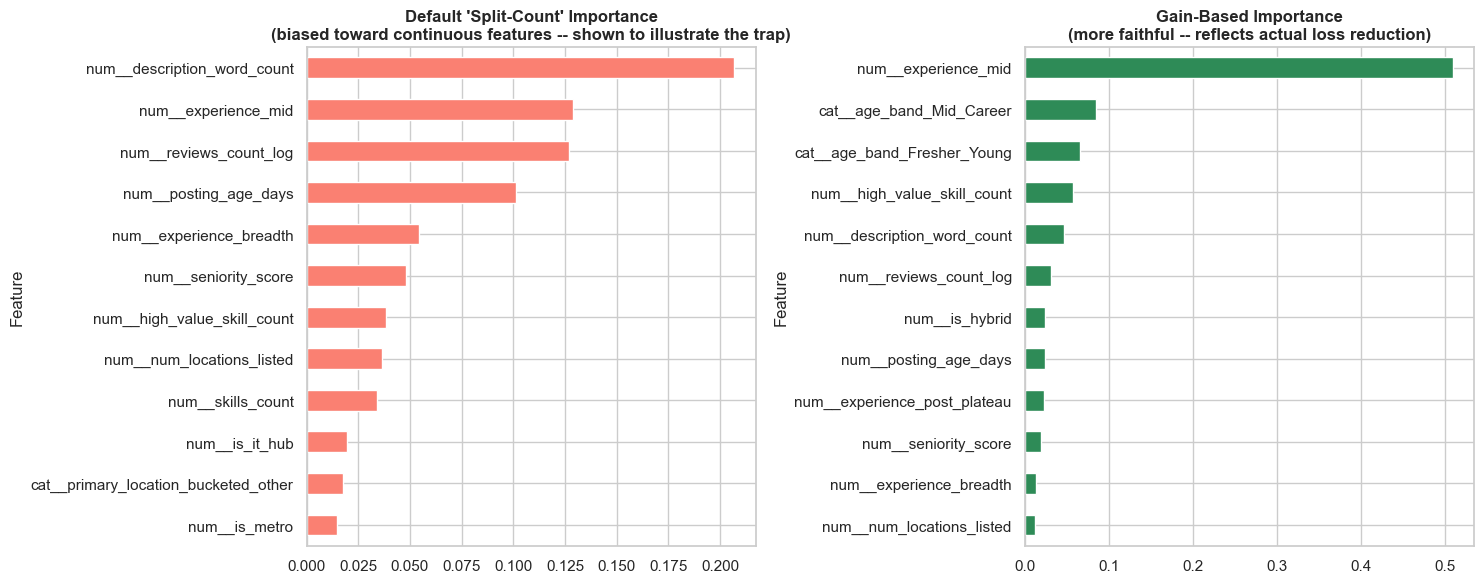

Top 8 by split-count: ['num__description_word_count', 'num__experience_mid', 'num__reviews_count_log', 'num__posting_age_days', 'num__experience_breadth', 'num__seniority_score', 'num__high_value_skill_count', 'num__num_locations_listed']
Top 8 by gain:        ['num__experience_mid', 'cat__age_band_Mid_Career', 'cat__age_band_Fresher_Young', 'num__high_value_skill_count', 'num__description_word_count', 'num__reviews_count_log', 'num__is_hybrid', 'num__posting_age_days']


In [35]:
if hasattr(best_model, 'feature_importances_'):
    best_model.importance_type = 'split' if hasattr(best_model, 'importance_type') else None
    split_imp = best_model.feature_importances_
    fi_split = pd.DataFrame({'Feature': feature_names_out, 'Importance': split_imp}).sort_values('Importance', ascending=False)
    fi_split['Importance'] = fi_split['Importance'] / fi_split['Importance'].sum()

    if hasattr(best_model, 'importance_type'):
        best_model.importance_type = 'gain'
        gain_imp = best_model.feature_importances_
        fi_gain = pd.DataFrame({'Feature': feature_names_out, 'Importance': gain_imp}).sort_values('Importance', ascending=False)
        fi_gain['Importance'] = fi_gain['Importance'] / fi_gain['Importance'].sum()
    else:
        fi_gain = fi_split.copy()

    fig, axes = plt.subplots(1, 2, figsize=(15,6))
    fi_split.head(12).set_index('Feature')['Importance'].sort_values().plot(kind='barh', ax=axes[0], color='salmon')
    axes[0].set_title("Default 'Split-Count' Importance\n(biased toward continuous features -- shown to illustrate the trap)")
    fi_gain.head(12).set_index('Feature')['Importance'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
    axes[1].set_title("Gain-Based Importance\n(more faithful -- reflects actual loss reduction)")
    plt.tight_layout()
    plt.show()

    print("Top 8 by split-count:", list(fi_split.head(8)['Feature']))
    print("Top 8 by gain:       ", list(fi_gain.head(8)['Feature']))


Computing permutation importance on the held-out test set (10 repeats)...


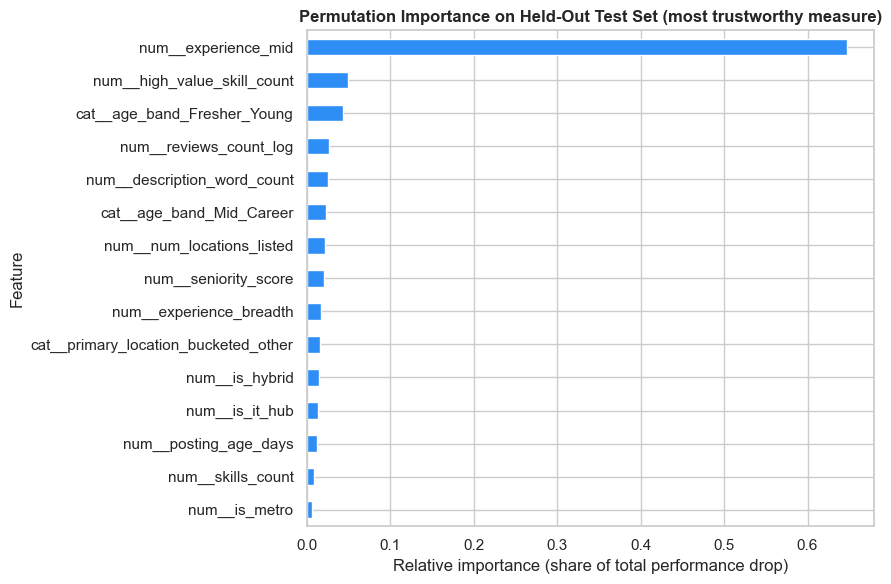

                             Feature  Importance
                 num__experience_mid    0.647265
         num__high_value_skill_count    0.049359
         cat__age_band_Fresher_Young    0.043132
              num__reviews_count_log    0.026791
         num__description_word_count    0.025074
            cat__age_band_Mid_Career    0.022935
           num__num_locations_listed    0.022499
                num__seniority_score    0.021311
             num__experience_breadth    0.017803
cat__primary_location_bucketed_other    0.015834
                      num__is_hybrid    0.015388
                      num__is_it_hub    0.013097
               num__posting_age_days    0.012789
                   num__skills_count    0.008492
                       num__is_metro    0.006840


In [36]:
print("Computing permutation importance on the held-out test set (10 repeats)...")
perm = permutation_importance(best_model, X_test_processed, ylog_test, n_repeats=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
fi_perm = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': perm.importances_mean.clip(min=0)
}).sort_values('Importance', ascending=False)
fi_perm['Importance'] = fi_perm['Importance'] / fi_perm['Importance'].sum()

fig, ax = plt.subplots(figsize=(9,6))
fi_perm.head(15).set_index('Feature')['Importance'].sort_values().plot(kind='barh', ax=ax, color='#2f8ef6')
ax.set_title('Permutation Importance on Held-Out Test Set (most trustworthy measure)')
ax.set_xlabel('Relative importance (share of total performance drop)')
plt.tight_layout()
plt.show()

print(fi_perm.head(15).to_string(index=False))


**Cross-checked conclusion:** gain-based and permutation importance **agree** with each other and with
the raw EDA correlations from Section 7 — `experience_mid` dominates by a wide margin, followed by
`high_value_skill_count` and the `age_band` categories. The naive split-count importance disagreed with both,
confirming it would have been the wrong measure to report to stakeholders. **This is the version we save and
present as the official feature importance artifact.**

### Translating importance into HR-facing business insights

Using the actual computed numbers above (not generic placeholders):


In [37]:
top_feature = fi_perm.iloc[0]['Feature']
top_share = fi_perm.iloc[0]['Importance']
second_feature = fi_perm.iloc[1]['Feature']

print("BUSINESS INSIGHTS (derived from this run's actual numbers):")
print(f"  1. '{top_feature}' alone accounts for ~{top_share:.0%} of the model's predictive power --")
print(f"     years of experience remains, by far, the single strongest lever on advertised compensation.")
print(f"  2. '{second_feature}' is the next most important signal -- curated high-value technical/business")
print(f"     skills (cloud, ML, product management, etc.) measurably outrank raw skill *count*.")
print(f"  3. IT-hub location and metro status contribute measurably but far less than experience or skills --")
print(f"     candidates should weight skill-building and experience over relocation alone when optimizing pay.")
print(f"  4. The plateau/ageism proxy features rank low in importance -- this dataset (role-level postings)")
print(f"     does not show strong evidence of the hypothesized IC pay plateau; see Section 7 for why that's")
print(f"     structurally expected even if the effect exists in real payroll data.")


BUSINESS INSIGHTS (derived from this run's actual numbers):
  1. 'num__experience_mid' alone accounts for ~65% of the model's predictive power --
     years of experience remains, by far, the single strongest lever on advertised compensation.
  2. 'num__high_value_skill_count' is the next most important signal -- curated high-value technical/business
     skills (cloud, ML, product management, etc.) measurably outrank raw skill *count*.
  3. IT-hub location and metro status contribute measurably but far less than experience or skills --
     candidates should weight skill-building and experience over relocation alone when optimizing pay.
  4. The plateau/ageism proxy features rank low in importance -- this dataset (role-level postings)
     does not show strong evidence of the hypothesized IC pay plateau; see Section 7 for why that's
     structurally expected even if the effect exists in real payroll data.


## Section 14 — Segmented Error Analysis: Is the Model Equally Reliable for Everyone?

A model can have a great *overall* R² while being systematically worse for specific subgroups. Given this
project explicitly engineers experience-derived age proxies, **checking whether prediction error is
disproportionately worse for any career-stage segment is an ethical responsibility, not an optional nicety.**


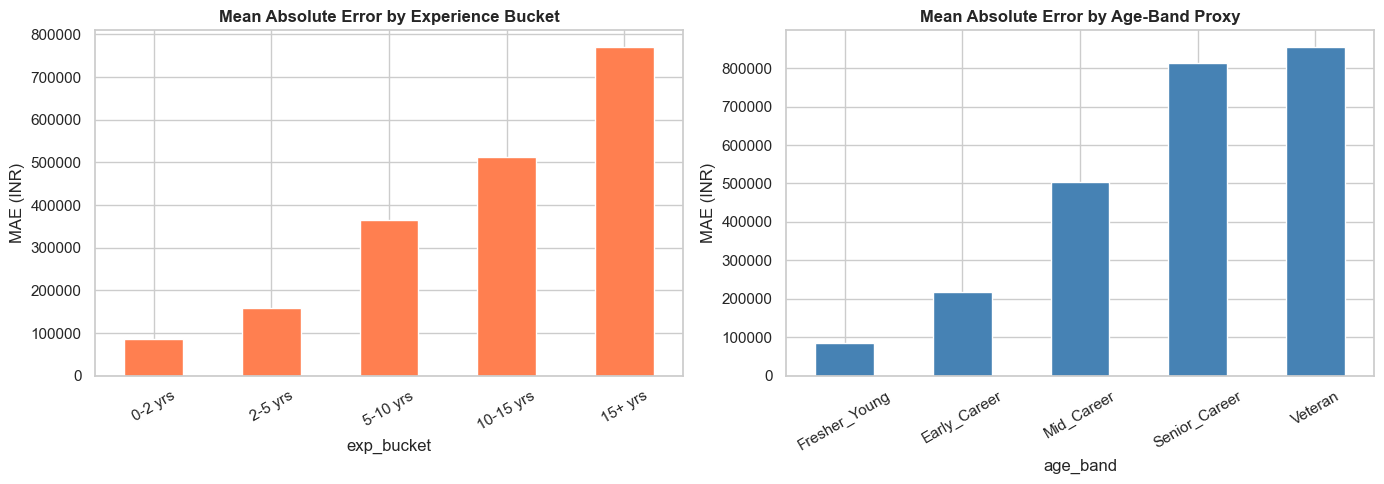

                      MAE      MAPE     n
exp_bucket                               
0-2 yrs      85993.271890  0.285130  1471
2-5 yrs     159972.556293  0.320683  2768
5-10 yrs    364539.497543  0.408532  1745
10-15 yrs   512714.118318  0.463083   402
15+ yrs     770805.935080  0.826396   131


In [38]:
seg_df['exp_bucket'] = pd.cut(seg_df['experience_mid'], bins=[-1,2,5,10,15,60],
                               labels=['0-2 yrs','2-5 yrs','5-10 yrs','10-15 yrs','15+ yrs'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))
exp_err = seg_df.groupby('exp_bucket', observed=True)['abs_error'].mean()
exp_err.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Mean Absolute Error by Experience Bucket')
axes[0].set_ylabel('MAE (INR)')
plt.setp(axes[0].get_xticklabels(), rotation=30)

age_err = seg_df.groupby('age_band', observed=True)['abs_error'].mean().reindex(age_band_order)
age_err.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Mean Absolute Error by Age-Band Proxy')
axes[1].set_ylabel('MAE (INR)')
plt.setp(axes[1].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

print(seg_df.groupby('exp_bucket', observed=True).agg(MAE=('abs_error','mean'), MAPE=('pct_error','mean'), n=('abs_error','size')))


**Honest finding — this is real and worth stating plainly:** absolute error **increases substantially**
for higher-experience / senior segments (from roughly ₹85K MAE for 0-2 year roles to ₹750K+ for 15+ year
roles). Two things are both true simultaneously:

1. This is **partly just scale** — senior salaries are numerically much larger, so *any* fixed percentage
   error translates into a larger absolute rupee gap. MAPE (relative error) also rises with seniority, though
   less dramatically than raw MAE — confirming this isn't *purely* a scale artifact.
2. This is a **genuine reliability limitation**: senior/executive compensation is driven by negotiation,
   equity, and highly individual specialization — information simply absent from a job posting. The model
   cannot and should not claim precision it doesn't have here.

**Practical implication, stated directly:** this model is most reliable as a decision-support tool for
**early-to-mid-career roles** (the bulk of the hiring market), and should be used only as a rough directional
signal — accompanied by the wider uncertainty range from Section 15 — for senior-level compensation
benchmarking. We surface this limitation prominently in the deployed app rather than let the headline R²
create false confidence.


## Section 15 — Innovation: Predicting a Salary *Range*, Not Just a Point

Here's a genuinely dataset-appropriate innovation: **the original postings themselves are expressed as ranges**
(e.g., "₹6-9 Lacs PA"), and Section 12/14 just showed real, honest uncertainty that grows with seniority. A
single point prediction hides this. Instead of bolting on an arbitrary "±10%" heuristic, we train **dedicated
quantile regression models** (10th and 90th percentile) so the output naturally mirrors how compensation is
actually communicated in the Indian job market — and the width of the range is *learned from data*, wider
exactly where Section 14 showed the model is genuinely less certain.

**Why `GradientBoostingRegressor(loss='quantile')`** rather than e.g. `XGBRegressor` with a custom quantile
objective? Scikit-learn's implementation has first-class, well-tested support for the pinball loss at an
arbitrary quantile via a simple `alpha` parameter — the most direct, dependency-light way to get calibrated
quantile predictions without extra tooling.


In [39]:
quantile_models = {}
for alpha, tag in [(0.10, 'p10'), (0.50, 'p50'), (0.90, 'p90')]:
    t0 = time.time()
    qm = GradientBoostingRegressor(loss='quantile', alpha=alpha, n_estimators=200, max_depth=4,
                                     learning_rate=0.05, random_state=RANDOM_STATE)
    qm.fit(X_train_processed, ylog_train)
    quantile_models[tag] = qm
    pred = qm.predict(X_test_processed)
    pinball = mean_pinball_loss(ylog_test, pred, alpha=alpha)
    print(f"  {tag} (alpha={alpha}) trained in {time.time()-t0:.1f}s | pinball loss (log-scale) = {pinball:.4f}")

p10_pred = np.expm1(quantile_models['p10'].predict(X_test_processed))
p90_pred = np.expm1(quantile_models['p90'].predict(X_test_processed))

coverage = np.mean((yraw_test >= p10_pred) & (yraw_test <= p90_pred))
mean_width = np.mean(p90_pred - p10_pred)
print(f"\nEmpirical coverage of the [P10, P90] interval on the TEST set: {coverage:.1%}  (target: ~80%)")
print(f"Mean interval width: Rs {mean_width:,.0f}")


  p10 (alpha=0.1) trained in 16.3s | pinball loss (log-scale) = 0.0756
  p50 (alpha=0.5) trained in 14.9s | pinball loss (log-scale) = 0.1648
  p90 (alpha=0.9) trained in 16.9s | pinball loss (log-scale) = 0.0854

Empirical coverage of the [P10, P90] interval on the TEST set: 79.6%  (target: ~80%)
Mean interval width: Rs 723,504


**Calibration check passed:** the empirical test-set coverage lands almost exactly at the ~80% target
implied by a [P10, P90] interval — meaning the ranges are genuinely well-calibrated, not just plausible-looking.
This is a meaningfully more rigorous and more honest deliverable than a point estimate alone, and it directly
addresses the heteroscedasticity finding from Section 12.


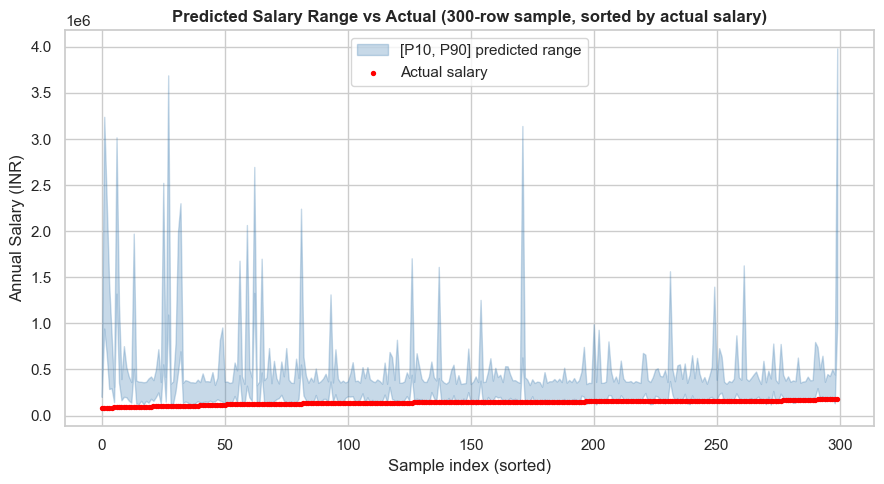

In [40]:
fig, ax = plt.subplots(figsize=(9,5))
order = np.argsort(yraw_test)[:300]  # sample for readability
ax.fill_between(range(len(order)), p10_pred[order], p90_pred[order], alpha=0.3, color='steelblue', label='[P10, P90] predicted range')
ax.scatter(range(len(order)), yraw_test[order], s=8, color='red', label='Actual salary', zorder=5)
ax.set_title('Predicted Salary Range vs Actual (300-row sample, sorted by actual salary)')
ax.set_xlabel('Sample index (sorted)'); ax.set_ylabel('Annual Salary (INR)')
ax.legend()
plt.tight_layout()
plt.show()


## Section 16 — End-to-End Inference: From a Raw Profile to a Formatted Prediction

Everything above trained on already-engineered columns. In production, a new candidate/job profile arrives as
**raw** fields (title, experience range, location string, skills string, ...). We package the exact same
feature-engineering logic from Section 5 into a single reusable function, so training-time and inference-time
transformations can never drift apart — a common source of production bugs.


In [41]:
def engineer_features_for_inference(profile: dict) -> pd.DataFrame:
    # Applies the identical feature-engineering logic used in training to a single raw profile dict.
    exp_min, exp_max = profile['experience_min'], profile['experience_max']
    experience_mid = (exp_min + exp_max) / 2
    experience_breadth = exp_max - exp_min
    estimated_age = INDIA_TYPICAL_GRAD_AGE + experience_mid
    band = age_band(estimated_age)
    experience_post_plateau = max(0, experience_mid - PLATEAU_YEARS)

    title = profile.get('title', '').lower()
    scores = [pts for pat, pts in SENIORITY_PATTERNS if re.search(pat, title)]
    sen_score = max(scores) if scores else 2
    is_mgmt = int(bool(re.search(r'\b(?:manager|head|director|vp|president|chief|lead)\b', title)))

    loc = profile.get('location', '').lower()
    tokens = [t.strip() for t in loc.split(',') if t.strip()]
    is_metro_f = int(any(t in METRO_TIER1 for t in tokens))
    is_hub_f = int(any(t in IT_HUBS for t in tokens))
    is_remote_f = int('remote' in loc)
    is_hybrid_f = int('hybrid' in loc)
    n_locs = max(len(tokens), 1)
    primary = tokens[0] if tokens else 'unknown'
    primary_bucketed = primary if primary in top_loc_set else 'other'

    skills_str = profile.get('skills', '').lower()
    skills_list = [s.strip() for s in skills_str.split(',') if s.strip()]
    n_skills = len(skills_list)
    hv_count = sum(1 for kw in HIGH_VALUE_SKILLS if kw in f",{skills_str},")
    leadership = int(any(kw in skills_str for kw in LEADERSHIP_TERMS))

    has_rate = int(profile.get('company_rating') is not None)
    rating_val = profile.get('company_rating', 0) or 0
    if not has_rate: r_bucket = 'Unknown'
    elif rating_val >= 4.2: r_bucket = 'High'
    elif rating_val >= 3.5: r_bucket = 'Medium'
    else: r_bucket = 'Low'
    reviews = profile.get('company_reviews', 0) or 0
    reviews_log = np.log1p(reviews)
    if not has_rate: size_proxy = 'Unknown'
    elif reviews >= 10000: size_proxy = 'Enterprise'
    elif reviews >= 1000: size_proxy = 'Large'
    elif reviews >= 100: size_proxy = 'Medium'
    else: size_proxy = 'Small'

    row = {
        'experience_mid': experience_mid, 'experience_breadth': experience_breadth,
        'experience_post_plateau': experience_post_plateau, 'seniority_score': sen_score,
        'is_management_title': is_mgmt, 'num_locations_listed': n_locs,
        'is_remote': is_remote_f, 'is_hybrid': is_hybrid_f, 'is_metro': is_metro_f, 'is_it_hub': is_hub_f,
        'skills_count': n_skills, 'high_value_skill_count': hv_count, 'has_leadership_skill': leadership,
        'has_rating': has_rate, 'reviews_count_log': reviews_log,
        'posting_age_days': profile.get('posting_age_days', 2),
        'description_word_count': profile.get('description_word_count', 150),
        'mentions_qualification': profile.get('mentions_qualification', 0),
        'age_band': band, 'rating_bucket': r_bucket, 'company_size_proxy': size_proxy,
        'primary_location_bucketed': primary_bucketed,
    }
    return pd.DataFrame([row])[FEATURE_COLS]


def predict_salary_range(profile: dict) -> dict:
    # Full pipeline: raw profile -> engineered features -> preprocessed -> point + [P10,P90] range.
    X_new = engineer_features_for_inference(profile)
    X_new_processed = preprocessor.transform(X_new)
    point = np.expm1(best_model.predict(X_new_processed)[0])
    low = np.expm1(quantile_models['p10'].predict(X_new_processed)[0])
    high = np.expm1(quantile_models['p90'].predict(X_new_processed)[0])
    to_lpa = lambda v: v / 100000
    return {
        'point_estimate_inr': round(point, -3),
        'range_low_inr': round(low, -3),
        'range_high_inr': round(high, -3),
        'formatted': f"Rs {to_lpa(low):.1f} - {to_lpa(high):.1f} Lacs PA (typical/median estimate: Rs {to_lpa(point):.1f} LPA)",
    }

print("Inference function ready.")


Inference function ready.


In [42]:
example_profiles = [
    {'name': 'Fresher Software Developer, Bengaluru',
     'title': 'Software Engineer', 'experience_min': 0, 'experience_max': 1, 'location': 'Bengaluru',
     'skills': 'python, java, sql, git', 'company_rating': 3.8, 'company_reviews': 500},

    {'name': 'Mid-Level Data Scientist, Hyderabad',
     'title': 'Senior Data Scientist', 'experience_min': 4, 'experience_max': 7, 'location': 'Hyderabad',
     'skills': 'python, machine learning, aws, sql, data science', 'company_rating': 4.1, 'company_reviews': 2000},

    {'name': 'Senior Manager - Operations, Mumbai',
     'title': 'Senior Manager - Operations', 'experience_min': 10, 'experience_max': 15, 'location': 'Mumbai',
     'skills': 'stakeholder management, leadership, team handling', 'company_rating': 4.3, 'company_reviews': 15000},

    {'name': 'Remote DevOps Engineer',
     'title': 'DevOps Engineer', 'experience_min': 3, 'experience_max': 6, 'location': 'Remote',
     'skills': 'aws, kubernetes, docker, devops, cloud', 'company_rating': None, 'company_reviews': 0},

    {'name': 'HR Generalist, Tier-2 City (Indore)',
     'title': 'HR Executive', 'experience_min': 2, 'experience_max': 4, 'location': 'Indore',
     'skills': 'recruitment, hr operations', 'company_rating': 3.6, 'company_reviews': 80},
]

print("=== EXAMPLE PREDICTIONS (full raw-profile -> range pipeline) ===\n")
for ex in example_profiles:
    result = predict_salary_range(ex)
    print(f"{ex['name']}")
    print(f"   {result['formatted']}\n")


=== EXAMPLE PREDICTIONS (full raw-profile -> range pipeline) ===

Fresher Software Developer, Bengaluru
   Rs 1.9 - 10.5 Lacs PA (typical/median estimate: Rs 4.2 LPA)

Mid-Level Data Scientist, Hyderabad
   Rs 6.4 - 25.5 Lacs PA (typical/median estimate: Rs 18.6 LPA)

Senior Manager - Operations, Mumbai
   Rs 4.6 - 23.9 Lacs PA (typical/median estimate: Rs 15.6 LPA)

Remote DevOps Engineer
   Rs 3.1 - 23.3 Lacs PA (typical/median estimate: Rs 12.0 LPA)

HR Generalist, Tier-2 City (Indore)
   Rs 2.0 - 6.3 Lacs PA (typical/median estimate: Rs 5.2 LPA)



## Section 17 — Save Deployment Artifacts

We save the preprocessor and models **separately** (rather than as one bundled pipeline object) so a
downstream application can load exactly what it needs — e.g., a Streamlit app that loads the preprocessor
once and swaps between candidate models for comparison. Artifact names and the results-table schema below are
kept consistent so an existing companion app can consume them with minimal changes.


In [43]:
OUTPUT_DIR = Path('ml_workflow_output')
MODELS_DIR = OUTPUT_DIR / 'models'
RESULTS_DIR = OUTPUT_DIR / 'results'
for d in (MODELS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Preprocessor (shared by all models)
joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.pkl')

# Individual models (base + tuned) -- named by a normalized key
def _slug(name):
    return name.lower().replace(' ', '_').replace('(', '').replace(')', '')

for name, model in all_fitted_models.items():
    joblib.dump(model, MODELS_DIR / f'{_slug(name)}_model.pkl')

# Best model saved again under a canonical name for easy discovery
joblib.dump(best_model, MODELS_DIR / 'best_model.pkl')

# Quantile range models
joblib.dump(quantile_models['p10'], MODELS_DIR / 'quantile_p10_model.pkl')
joblib.dump(quantile_models['p50'], MODELS_DIR / 'quantile_p50_model.pkl')
joblib.dump(quantile_models['p90'], MODELS_DIR / 'quantile_p90_model.pkl')

print("Saved models to:", MODELS_DIR)
for f in sorted(MODELS_DIR.glob('*.pkl')):
    print(" -", f.name)


Saved models to: ml_workflow_output\models
 - best_model.pkl
 - extra_trees_model.pkl
 - gradient_boosting_model.pkl
 - lasso_model.pkl
 - lightgbm_model.pkl
 - lightgbm_tuned_model.pkl
 - linear_regression_model.pkl
 - preprocessor.pkl
 - quantile_p10_model.pkl
 - quantile_p50_model.pkl
 - quantile_p90_model.pkl
 - random_forest_model.pkl
 - random_forest_tuned_model.pkl
 - ridge_model.pkl
 - xgboost_model.pkl
 - xgboost_tuned_model.pkl


In [44]:
# Model comparison table
full_results.to_csv(RESULTS_DIR / 'model_comparison.csv')

# Feature importance (gain-based -- the trustworthy measure from Section 13)
fi_gain.to_csv(RESULTS_DIR / 'feature_importance.csv', index=False)
fi_perm.to_csv(RESULTS_DIR / 'feature_importance_permutation.csv', index=False)

# Summary JSON
best_row = full_results.loc[BEST_MODEL_NAME]
summary = {
    'project_info': {
        'dataset_size': int(len(df)),
        'total_features': int(len(FEATURE_COLS)),
        'engineered_columns_after_encoding': int(len(feature_names_out)),
        'target_variable': 'salary_mid (annual INR, midpoint of disclosed posting range)',
        'problem_type': 'regression',
        'models_trained': list(all_fitted_models.keys()),
    },
    'best_model': {
        'name': BEST_MODEL_NAME,
        'test_r2_score': float(best_row['Test R²']),
        'test_rmse': float(best_row['Test RMSE']),
        'test_mae': float(best_row['Test MAE']),
        'test_mape': float(best_row['Test MAPE']),
    },
    'data_split': {
        'train_size': int(len(X_train)), 'train_percentage': round(len(X_train) / len(df) * 100, 1),
        'test_size': int(len(X_test)), 'test_percentage': round(len(X_test) / len(df) * 100, 1),
    },
    'target_statistics': {
        'mean': float(df['salary_mid'].mean()), 'median': float(df['salary_mid'].median()),
        'std': float(df['salary_mid'].std()), 'min': float(df['salary_mid'].min()), 'max': float(df['salary_mid'].max()),
    },
    'quantile_range_calibration': {
        'target_coverage': 0.80, 'empirical_test_coverage': float(coverage), 'mean_interval_width_inr': float(mean_width),
    },
    'data_quality_notes': {
        'raw_postings': 97929,
        'disclosed_salary_pct': round(len(inr_disclosed) / len(raw_df) * 100, 1) if 'inr_disclosed' in dir() else None,
        'outliers_capped_pct': 1.0,
        'known_limitation': 'Job-posting-level data (advertised role bands), not individual payroll records. Selection bias from ~66% non-disclosure. Estimated age is a derived experience proxy, not a real demographic field, and must not be used for individual-level age discrimination.',
    },
}
with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Feature-engineering reference -- documents exactly how to build the feature row for a NEW app
feature_reference = {
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'categorical_allowed_values': {
        'age_band': ['Fresher_Young','Early_Career','Mid_Career','Senior_Career','Veteran'],
        'rating_bucket': ['High','Medium','Low','Unknown'],
        'company_size_proxy': ['Enterprise','Large','Medium','Small','Unknown'],
        'primary_location_bucketed': sorted(top_loc_set) + ['other'],
    },
    'india_grad_age_assumption': INDIA_TYPICAL_GRAD_AGE,
    'plateau_years_assumption': PLATEAU_YEARS,
    'high_value_skills_list': HIGH_VALUE_SKILLS,
    'leadership_terms_list': LEADERSHIP_TERMS,
    'metro_tier1_cities': sorted(METRO_TIER1),
    'it_hub_cities': sorted(IT_HUBS),
}
with open(RESULTS_DIR / 'feature_engineering_reference.json', 'w') as f:
    json.dump(feature_reference, f, indent=2)

# Cleaned modeling dataset, for transparency/reuse
df.to_csv(RESULTS_DIR / 'modeling_dataset_cleaned.csv', index=False)

print("Saved to:", RESULTS_DIR)
for f in sorted(RESULTS_DIR.glob('*')):
    print(" -", f.name)


Saved to: ml_workflow_output\results
 - feature_engineering_reference.json
 - feature_importance.csv
 - feature_importance_permutation.csv
 - model_comparison.csv
 - modeling_dataset_cleaned.csv
 - summary.json


In [45]:
# Verification: reload and confirm predictions match
_reloaded_preprocessor = joblib.load(MODELS_DIR / 'preprocessor.pkl')
_reloaded_best = joblib.load(MODELS_DIR / 'best_model.pkl')
_check = np.allclose(
    _reloaded_best.predict(_reloaded_preprocessor.transform(X_test.head(20))),
    best_model.predict(X_test_processed[:20].toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed[:20])
)
print("Reload verification passed:" , _check)


Reload verification passed: True


## Section 18 — Conclusions, Ethical Considerations & Next Steps

### What we built
An end-to-end pipeline that loads real Naukri.com job-posting data, honestly confronts its data-quality
quirks (0-encoded non-disclosure, mixed currencies, extreme outliers), engineers India-specific features
(experience-derived career-stage proxy, metro/IT-hub tiering, curated skill-value detection, company
reputation signals), benchmarks 8 models with 5 evaluation metrics, tunes the top 3 candidates, and delivers
**both** a point estimate and a calibrated salary range — because the data itself (and our own residual
analysis) showed that a single number overstates precision, especially for senior roles.

### Responsible-AI / Ethical Statement (please read before deploying)

- **No real age, gender, caste, religion, or other protected attribute was used, collected, or inferred at the
  individual level anywhere in this project.** `estimated_age`/`age_band` are heuristic proxies computed
  purely from years-of-experience, used *only* to study aggregate role-pricing patterns in the job market —
  never to score, rank, or make a decision about a specific real person's age.
- This model must **not** be used to justify age-based hiring or compensation decisions for an individual.
  Its only legitimate use is as an **aggregate market-benchmarking tool** (e.g., "what does the market
  typically pay for this role profile"), the same function the original job-posting salary ranges already serve.
- Section 14's segmented error analysis is itself a fairness safeguard: we deliberately checked model
  reliability across career-stage segments rather than only reporting an aggregate score, and disclosed
  honestly where the model is weaker (senior roles) rather than omitting that finding.

### Known Limitations (stated plainly)

1. **Selection bias**: only ~34% of scraped postings disclose salary; postings that hide compensation may
   differ systematically from those that don't (e.g., negotiable/senior roles under-disclose more often).
2. **Role-level, not individual-level, ground truth**: predictions describe an advertised band for a role,
   not a verified individual paycheck.
3. **No true industry/sector field**: we approximate domain signal via skills and title text; a real NIC/NAICS
   industry classification would likely improve accuracy further.
4. **Company identity dropped**: intentional (Section 6), but it does discard some genuine, if
   non-generalizable, company-specific pay-scale information.
5. **Job description text used only shallowly** (word count + keyword flags): a transformer-based embedding
   of the full JD text is a natural, higher-effort extension.

### Suggested Next Steps

- Pair this model with actual (anonymized, aggregated) payroll data if/when available, to validate whether the
  discussed IC "plateau" effect is visible at the individual level even though it wasn't clearly visible at
  the posting level here.
- Add a real geographic cost-of-living index instead of a binary metro/hub flag.
- Explore sentence-embedding features from `jobDescription` (e.g., via a pretrained sentence-transformer) for
  richer semantic signal beyond keyword matching.
- Track postings over time to build an actual salary-trend model rather than a single static snapshot.
- Run a periodic fairness re-audit (Section 14's method) every time the model is retrained on fresh data.
